## Librerías

In [1]:
import re
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from google.colab import files

## Constantes y funciones

### Constantes globales

In [2]:
QPSK_CONSTELLATION = np.array([
    0.707 + 0.707j,   # 00
   -0.707 + 0.707j,   # 01
   -0.707 - 0.707j,   # 10
    0.707 - 0.707j    # 11
])

ASK4_CONSTELLATION = np.array([
   -3,   # 00
   -1,   # 01
    1,   # 10
    3    # 11
])

# DISTANCES = [0, 2, 20, 40]

### Manipulación de señales y bits

In [3]:
def sync_signals(tx, rx):
    """
    Sincroniza correlacionando componentes I y Q de forma independiente.
    """
    eps = 1e-9

    # Normalización
    def normalize_signal(s):
        # Separamos componentes para normalizar desvíos de DC y escala de forma independiente
        components = [s.real, s.imag]
        norm_comp = [(c - np.mean(c)) / (np.std(c) + eps) for c in components]
        return norm_comp

    tx_i, tx_q = normalize_signal(tx)
    rx_i, rx_q = normalize_signal(rx)

    # Correlaciones cruzadas (II y QQ)
    corr_ii = np.correlate(rx_i, tx_i, mode="full")
    corr_qq = np.correlate(rx_q, tx_q, mode="full")

    # Suma y detección de retardo (delay)
    total_corr = corr_ii + corr_qq
    delay = np.argmax(total_corr) - (len(tx) - 1)

    # Recorte y alineación
    if delay < 0:
        # El receptor empezó después que el transmisor (o hay pérdida inicial)
        rx_sync = rx[: len(tx) + delay]
        tx_sync = tx[-delay : -delay + len(rx_sync)]
    else:
        # El receptor tiene un retraso positivo
        rx_sync = rx[delay : delay + len(tx)]
        tx_sync = tx[: len(rx_sync)]

    return tx_sync, rx_sync, delay, corr_ii, corr_qq

def plot_constellation(signal, metadata=None, title="Constellation Diagram"):
    """
    Grafica el diagrama de constelación.
    """
    plt.figure(figsize=(6, 7))
    plt.scatter(signal.real, signal.imag, s=1, alpha=0.5, color='royalblue')

    # Estética y ejes
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    plt.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    plt.grid(True, linestyle=':', alpha=0.6)

    # Formateo de metadata enfocado en SNR y OSNR
    if metadata:
        # Extraemos valores con un fallback de "N/A" si no existen
        snr = metadata.get('snr_db', 'N/A')
        osnr = metadata.get('osnr_db', 'N/A')
        pwr = metadata.get('launch_power_dbm', 'N/A')
        dist = metadata.get('distance_km', 'N/A')

        full_title = f"{title}\nSNR: {snr} dB | OSNR: {osnr} dB"
        sub_info = f"Power: {pwr} dBm | Distance: {dist} km"

        plt.suptitle(full_title, fontsize=12, fontweight='bold')
        plt.title(sub_info, fontsize=9, color='dimgray')
    else:
        plt.title(title)

    # Ajuste dinámico de límites para evitar distorsión
    limit = np.max(np.abs(signal)) * 1.2 if len(signal) > 0 else 1
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)

    plt.xlabel("In-Phase (I)")
    plt.ylabel("Quadrature (Q)")
    plt.gca().set_aspect('equal')
    plt.tight_layout()
    plt.show()

def plot_correlation_results(corr_ii, corr_qq, lags, metadata=None, title="Correlation Analysis"):
    """
    Graficar correlaciones real y compleja.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Metadata en el encabezado
    if metadata:
        snr = metadata.get('snr_db', 'N/A')
        osnr = metadata.get('osnr_db', 'N/A')
        fig.suptitle(f"{title}\nSNR: {snr} dB | OSNR: {osnr} dB", fontsize=12, fontweight='bold')

    # Configuración de ejes para I y Q
    plots = [
        (ax1, corr_ii, "I", "dodgerblue"),
        (ax2, corr_qq, "Q", "limegreen")
    ]

    for ax, data, label, color in plots:
        peak_idx = np.argmax(np.abs(data))
        delay = lags[peak_idx]

        ax.plot(lags, data, label=label, color=color, lw=1.2)
        ax.axvline(delay, color='red', ls='--', alpha=0.7, label=f"Peak: {delay}")
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(True, alpha=0.3)

    plt.xlabel("Lag (samples)")
    plt.tight_layout()
    plt.show()

### Modulación y demodulación

In [4]:
def modulate(bits, constellation):
    """
    Modula bits a símbolos.
    """
    # Determinar bits por símbolo (k) basado en el tamaño de la constelación
    M = len(constellation)
    k = int(np.log2(M))

    # Padding: Asegurar que el flujo de bits sea múltiplo de k
    remainder = len(bits) % k
    if remainder != 0:
        bits = np.append(bits, np.zeros(k - remainder, dtype=int))

    # Agrupar bits y convertir a índices decimales
    # Reshape para tener filas de tamaño 'k'
    reshaped_bits = bits.reshape(-1, k)

    # Convertir cada fila de bits a un índice decimal (MSB primero)
    # [1, 0] -> 1*2^1 + 0*2^0 = 2
    powers = 2**np.arange(k-1, -1, -1)
    indexes = np.dot(reshaped_bits, powers)

    return constellation[indexes]

def demodulate(signal, constellation):
    """
    Demodula buscando el símbolo más cercano (Hard Decision).
    """
    M = len(constellation)
    k = int(np.log2(M))

    # 1. Encontrar el índice del símbolo más cercano en la constelación para cada punto
    distances = np.abs(signal[:, None] - constellation[None, :])
    sym_indices = np.argmin(distances, axis=1)

    # 2. Convertir índices decimales de vuelta a bits
    # Creamos una matriz donde cada fila es la representación binaria del índice
    # Ejemplo para k=2: 0->[0,0], 1->[0,1], 2->[1,0], 3->[1,1]
    bit_map = np.array([[int(b) for b in format(i, f'0{k}b')] for i in range(M)])

    # Extraemos los bits correspondientes a los índices detectados
    bits = bit_map[sym_indices].flatten()

    return bits

### Utilidades

In [5]:
def extract_value(pattern, text, conversion_func=float):
    """
    Función interna genérica para buscar un patrón en el texto.
    """
    # Buscar el patrón ignorando mayúsculas/minúsculas
    match = re.search(pattern, text, re.IGNORECASE)
    if match:
        value_str = match.group(1)
        # Reemplazar la 'p' por punto decimal para poder convertir a float
        if 'p' in value_str:
            value_str = value_str.replace('p', '.')
        return conversion_func(value_str)
    return None

def get_launch_power(filename):
    # Busca potencia en dBm (soporta negativos, ej: -3dBm o 0p5dBm)
    return extract_value(r"([-+]?\d+(?:p\d+)?)dbm", filename)

def get_distance(filename):
    return extract_value(r"(\d+(?:p\d+)?)km", filename)

def get_osnr(filename):
    return extract_value(r"osnr(\d+p\d+)db", filename)

def get_snr(filename):
    return extract_value(r"(?<!o)snr(\d+p\d+)db", filename)

def get_carrier_freq(filename):
    return extract_value(r"(\d+)mhz", filename, int)

def get_bitrate(filename):
    return extract_value(r"(\d+)mbps", filename, int)

def parse_filename_metadata(filename):
    """
    Extrae todos los parámetros y los devuelve en un diccionario.
    """
    metadata = {
        "launch_power_dbm": get_launch_power(filename),
        "distance_km":      get_distance(filename),
        "osnr_db":          get_osnr(filename),
        "snr_db":           get_snr(filename),
        "freq_mhz":         get_carrier_freq(filename),
        "bitrate_mbps":     get_bitrate(filename)
    }
    return metadata

def load_results(output_filename):
    # Intentar cargar la base de datos existente
    if os.path.exists(output_filename):
        results_df = pd.read_csv(output_filename)
        # Usamos un set de los nombres de archivos ya procesados para una búsqueda rápida
        processed_files = set(results_df['filename'].unique())
        # Convertimos el dataframe a lista de diccionarios para seguir añadiendo
        results_list = results_df.to_dict('records')
        print(f"✅ Base de datos cargada: {len(results_list)} registros previos.")
    else:
        results_list = []
        processed_files = set()
        print("❌ No hay resultados previos. Se creará una nueva base de datos.")
    return results_list, processed_files

## Proceso principal

In [6]:
def main_pipeline(rx_paths, processed_files, results_list, output_filename):
    # Iniciamos el cronómetro global
    start_time = time.time()

    for path in rx_paths:
        if not os.path.exists(path):
            print(f"⚠️ Saltando {path}: archivo no encontrado.")
            continue

        current_npz = np.load(path, allow_pickle=True)
        all_files = current_npz.files

        # Filtrar archivos que ya procesamos para que la barra de progreso sea real
        files_to_process = [f for f in all_files if f not in processed_files]
        skipped = len(all_files) - len(files_to_process)

        print(f"\n📂 NPZ: {path}")
        if skipped > 0:
            print(f"⏩ Saltando {skipped} archivos ya procesados...")

        # Barra de progreso para los archivos de este NPZ
        pbar = tqdm(files_to_process, desc=f"Procesando {path}", unit="file")

        for name in pbar:
            metadata = parse_filename_metadata(name.lower())
            rx_signal = current_npz[name]
            rotation_results = []

            # Actualizamos el texto de la barra con el OSNR actual (opcional)
            pbar.set_postfix(OSNR=metadata.get('osnr_db', '?'))

            for rot in [1, 1j, -1, -1j]:
                rx_rotated = rx_signal * rot

                # Sincronización y alineación
                tx_s, rx_s, delay, _, _ = sync_signals(tx_ref, rx_rotated)

                # Demodulación y cálculo de BER
                b_ref = demodulate(tx_s, QPSK_CONSTELLATION)
                b_rx  = demodulate(rx_s, QPSK_CONSTELLATION)

                n = min(len(b_ref), len(b_rx))
                if n == 0: continue

                ber = np.mean(b_ref[:n] != b_rx[:n])
                rotation_results.append({'ber': ber, 'delay': delay})

            if rotation_results:
                best_case = min(rotation_results, key=lambda x: x['ber'])
                metadata.update({
                    'filename': name,
                    'ber': best_case['ber'],
                    'detected_delay': best_case['delay'],
                    'npz_source': path
                })
                results_list.append(metadata)
                processed_files.add(name)

        # Guardado intermedio por cada NPZ terminado
        pd.DataFrame(results_list).to_csv(output_filename, index=False)
        print(f"✅ Progreso guardado. Total en BD: {len(results_list)}")
        files.download(output_filename)

    total_duration = time.time() - start_time
    print(f"\n✨ Pipeline finalizado en {total_duration:.2f} segundos.")

### Cargar datos

In [7]:
# Bits transmitidos (TX)
!gdown 1RXSmwwvAFrpuyjo6c7dU_lzNQmnJ80d5

# DFB (usando pasos de 1 dB)
# 0 km
# !gdown 1ERpfPPJqVCY3gV9Vxo4svllCwcyrIjzX
# # 2 km
# !gdown 1QRH4PaurMJRMW2gApy397tgAaNtPr1mA
# # 20 km
# !gdown 1wG_3o6nLCNEbYS0vhqqAYwu5cWXX7DHu
# # 40 km
# !gdown 1eOyne5EZ_WBe0zEzV1iYwHGWm7_qZM9r

# DFB (usando pasos de 0.4 dB) DATOS VIEJOS:
# 0 km
#!gdown 1rhLsooKt0OV0lrZVP1Tv2R3XzUR28Pa7
# 2 km
#!gdown 1D2BV7jwCBB-Q5ngGfRHyGz87j68BXqBI
# 20 km
#!gdown 1gNT1T0B4ZzBa9BULal063jYttPCNKuRB
# 40 km
#!gdown 19rMA29ybHCWq4aYP1kteFCLPbA3NnxN5

# DFB (usando pasos de 0.4 dB) DATOS NUEVOS:
# 0 km
#!gdown 1lHsOplgdWLUOnZvE2cTtMWhe0hfcj1n7
# 2 km
#!gdown 1e6ocx9IRUdCGdB_vTwo7XRJ68iQKtou2
# 20 km
#!gdown 1MseAIVe3aG2ki5nDwzLeqssaFBLDW25M
# 40 km
#!gdown 1LkbZdK20vxYDR4bf3n_pPqNIuAvcCVdA


# USPL (usando pasos de alatorios en la tabla)
# 0 km
#!gdown 1S7dZJFU5nZFi99cTtx1hugZ8P6Zx_c1Q
# 2 km
#!gdown 1qUlL2duIytZPXC9eH7dJp3_fioQSxSEd
# 20 km
#!gdown 1LZYJt0qmJDQxJ66LL1sEkT0IOUc9Spd1
# 40 km
#!gdown 1aUmI5BqZv37t6I6ixot2YwmhR5qm0hc9


# DFB 900 (prueba 8)
# 0 km
!gdown 1RdrGcxlT6vhVXpyr2maQICFmWJKyFRED
# 2 km
!gdown 1WltaGHTxjCvmrHnCryZ7iR4X1kYH2c5M
# 20 km
!gdown 1wOY-A6MF5U6Dva_ajZgpDB_kwC1qMQUH
# 40 km
!gdown 1_UuqmOiOlGHqsv7Nwx9TAwGICWdqtTPw



# Resultados
# DFB (usando pasos de 1 dB)
#!gdown 19JF1TEHVNC4lDzKaHGdE6ki5wGvYF8aC
# DFB (Prueba 3)
#!gdown 1KFC7sAuiMde7kHRxNWL8hwThAPWJy8b0
# DFB (Prueba 4)
!gdown 1bZwDiralez_MNQPv4sJeV31McYt29rlJ
# DFB (prueba 5)
!gdown 19MmzPZSGMbS9OaDNHRaUtMR5D4_miK8l
# DFB (usando pasos de 0.4 dB)
#!gdown 1vMQfpNP6n7BkgWic5PhBzfVbaO1hcnSq
# DFB (prueba 6 definitiva)
!gdown 1QAYBzfkOt84kt1z_cgosrJ37AiDFCEqz

#USPL (Prueba 7)
!gdown 1mr8ERotmW9w3VjZAifpuAB9rDGtKTa9O

#DFB 900 Mhz(Prueba 8)
!gdown 1jrKjpMuAf23pfmRxbM6oCgw03p0ogjIJ



Downloading...
From: https://drive.google.com/uc?id=1RXSmwwvAFrpuyjo6c7dU_lzNQmnJ80d5
To: /content/tx.txt
100% 131k/131k [00:00<00:00, 77.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1RdrGcxlT6vhVXpyr2maQICFmWJKyFRED
From (redirected): https://drive.google.com/uc?id=1RdrGcxlT6vhVXpyr2maQICFmWJKyFRED&confirm=t&uuid=c413bada-b00a-4da8-86a5-6b007a39fa52
To: /content/rof_dfb_0dBm_0km_900mhz_1p88mbps.npz
100% 186M/186M [00:01<00:00, 118MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1WltaGHTxjCvmrHnCryZ7iR4X1kYH2c5M
From (redirected): https://drive.google.com/uc?id=1WltaGHTxjCvmrHnCryZ7iR4X1kYH2c5M&confirm=t&uuid=ae0b7336-0057-41f1-a050-04fb3a06dddd
To: /content/rof_dfb_0dBm_2km_900mhz_1p88mbps.npz
100% 189M/189M [00:05<00:00, 35.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wOY-A6MF5U6Dva_ajZgpDB_kwC1qMQUH
From (redirected): https://drive.google.com/uc?id=1wOY-A6MF5U6Dva_ajZgpDB_kwC1qMQUH&confirm=t&uuid=29034b29-0153-4

In [8]:
# Ruta al archivo de bits
TX_PATH = "tx.txt"

with open(TX_PATH, "r") as f:
    bitstring1 = f.read().strip()

print("Cantidad de bits:", len(bitstring1))
print("Primeros 50 bits:", bitstring1[:50])

bits_tx = np.array([int(b) for b in bitstring1], dtype=np.uint8)

# Referencia de transmisión
tx_ref = modulate(bits_tx, QPSK_CONSTELLATION)

Cantidad de bits: 131072
Primeros 50 bits: 00000101010101010001011111111110110101000000010000


## DFB - USPL

In [ ]:
# WARN: Usamos datos antiguos porque los nuevos tardan demasiado en procesar
POWER = "0"
FREQ = "900"
#DATA_RATE = "2"
DATA_RATE = "1p88"
LASER_TYPE = "dfb"
DISTANCES = [0, 2, 20, 40]

#rx_paths_dfb = [f"rof_{POWER}dBm_{d}km_{FREQ}mhz_{DATA_RATE}mbps.npz" for d in DISTANCES]
rx_paths_dfb = [f"rof_{LASER_TYPE}_{POWER}dBm_{d}km_{FREQ}mhz_{DATA_RATE}mbps.npz" for d in DISTANCES]

data0, data2, data20, data40 = 0, 0, 0, 0
data_dfb = [data0, data2, data20, data40]

for datum, path in zip(data_dfb, rx_paths_dfb):
  datum = np.load(path, allow_pickle=True)
  print(f"📂 Datos de {path} cargados con {len(datum)} archivos")

📂 Datos de rof_dfb_0dBm_0km_900mhz_1p88mbps.npz cargados con 80 archivos
📂 Datos de rof_dfb_0dBm_2km_900mhz_1p88mbps.npz cargados con 81 archivos
📂 Datos de rof_dfb_0dBm_20km_900mhz_1p88mbps.npz cargados con 71 archivos
📂 Datos de rof_dfb_0dBm_40km_900mhz_1p88mbps.npz cargados con 70 archivos


### Evaluar

In [ ]:
#output_filename_dfb = f"results_qpsk_{LASER_TYPE}.csv"
output_filename_dfb = f"results_qpsk_{LASER_TYPE}_extended_Prueba8_900.csv"
results_list_dfb, processed_files_dfb = load_results(output_filename_dfb)

✅ Base de datos cargada: 302 registros previos.


In [ ]:
main_pipeline(rx_paths_dfb, processed_files_dfb, results_list_dfb, output_filename_dfb)


📂 NPZ: rof_dfb_0dBm_0km_900mhz_1p88mbps.npz


Procesando rof_dfb_0dBm_0km_900mhz_1p88mbps.npz:   0%|          | 0/80 [00:00<?, ?file/s]

✅ Progreso guardado. Total en BD: 80


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

Procesando rof_dfb_0dBm_40km_900mhz_1p88mbps.npz:   0%|          | 0/70 [00:00<?, ?file/s]

✅ Progreso guardado. Total en BD: 302


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✨ Pipeline finalizado en 20663.39 segundos.


### Estimación teórica:

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("results_qpsk_dfb_extended_Prueba7.csv")

# EVM teórica desde SNR (asumiendo AWGN)
snr_lin          = 10 ** (df['snr_db'] / 10)
df['evm_rms_pct'] = 100 / np.sqrt(snr_lin)
df['evm_db']      = 20 * np.log10(df['evm_rms_pct'] / 100)
df['evm_peak_pct'] = df['evm_rms_pct'] * np.sqrt(2)

df.to_csv("results_qpsk_dfb_extended_Prueba6.csv", index=False)
print(f" Guardado con {len(df)} filas")
print(df[['snr_db','evm_rms_pct','evm_db','evm_peak_pct']].describe().round(3))

 Guardado con 439 filas
        snr_db  evm_rms_pct   evm_db  evm_peak_pct
count  439.000      439.000  439.000       439.000
mean    10.874       29.716  -10.874        42.025
std      2.416        8.246    2.416        11.661
min      5.190       17.022  -15.380        24.072
25%      8.550       22.504  -12.955        31.825
50%     10.890       28.543  -10.890        40.366
75%     12.955       37.368   -8.550        52.846
max     15.380       55.017   -5.190        77.806


### Graficar

### Graficas simposio:


Prueba6 — Filas después de limpieza: 383
Prueba7 — Filas después de limpieza: 204


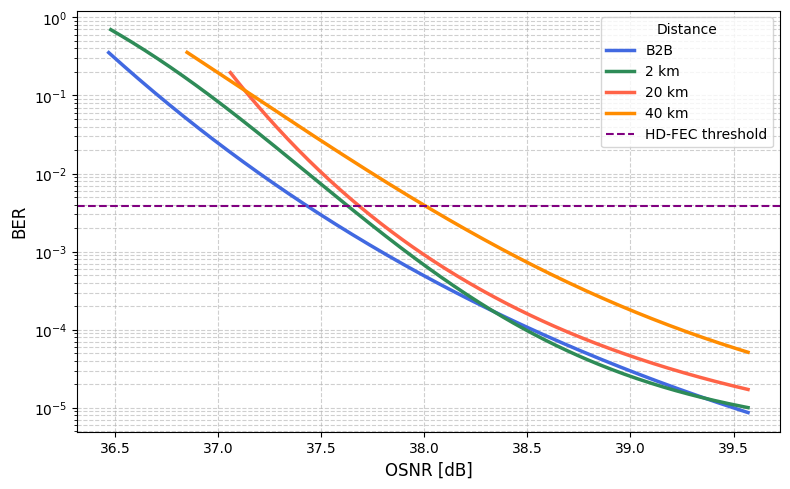

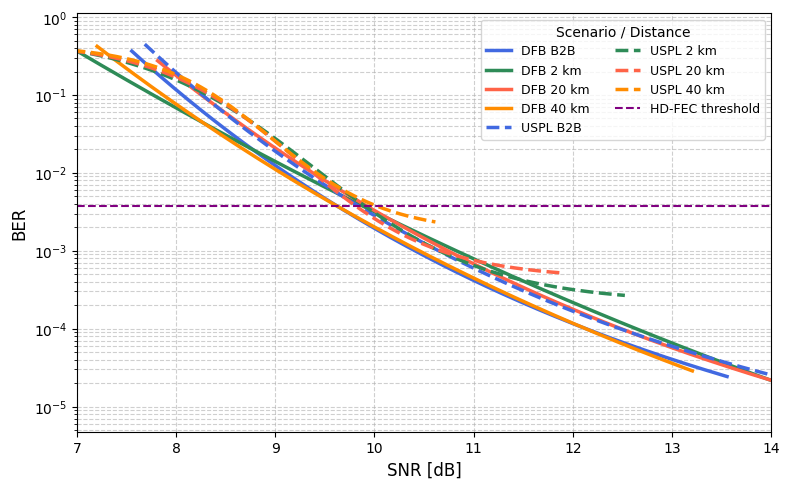

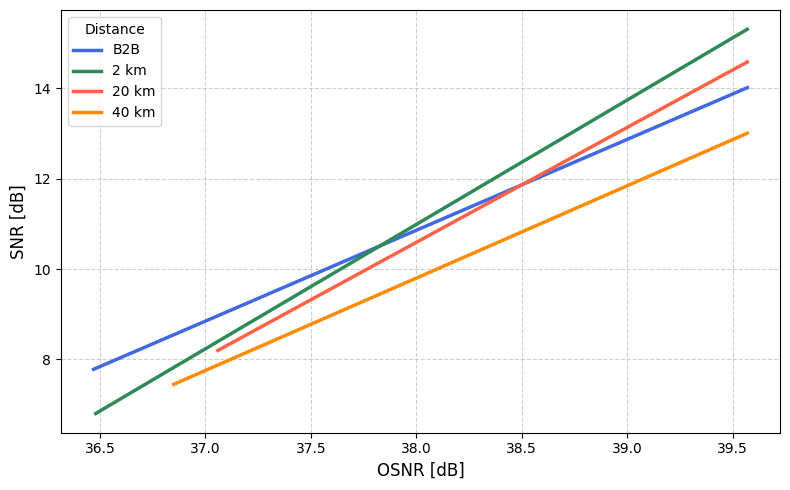

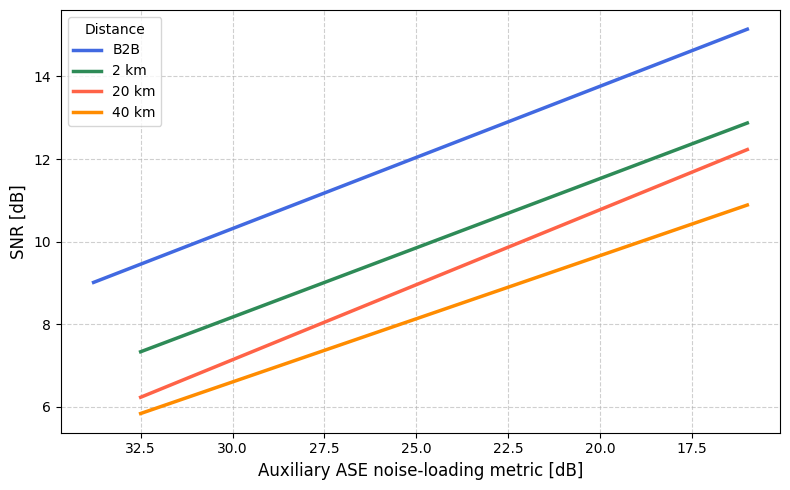

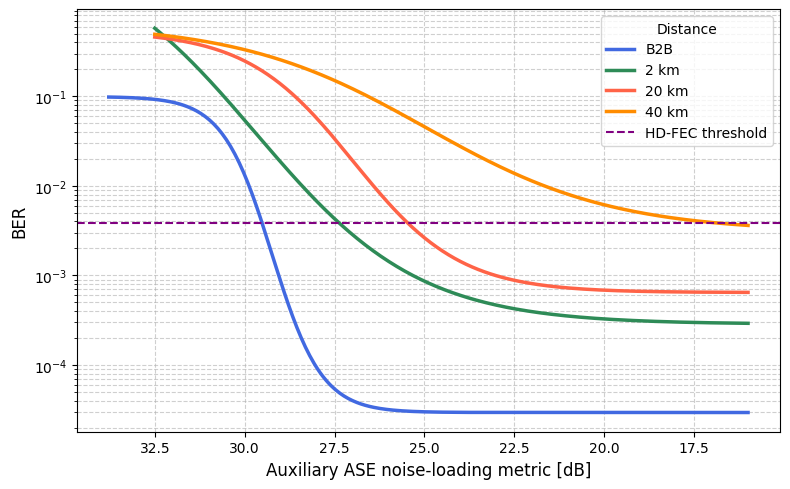

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress

# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

df  = pd.read_csv("results_qpsk_dfb_extended_Prueba6.csv")
df7 = pd.read_csv("results_qpsk_dfb_extended_Prueba7.csv")

# ─────────────────────────────────────────────
# MAPEO DE OSNR — Prueba 7
# Los valores 1-6 en osnr_db se reemplazan por
# los valores reales medidos de OSNR
# ─────────────────────────────────────────────

OSNR_MAP = {
    1: 16.0,
    2: 25.5,
    3: 28.5,
    4: 30.5,
    5: 32.5,
    6: 33.78
}
df7['osnr_db'] = df7['osnr_db'].map(OSNR_MAP).fillna(df7['osnr_db'])

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS — Prueba 6
# ─────────────────────────────────────────────

df_clean = df[~((df['distance_km'] == 2) &
                (df['osnr_db'] > 39) &
                (df['ber'] > 0.01))]
df_clean = df_clean[df_clean['ber'] > 0]

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS — Prueba 7
# ─────────────────────────────────────────────

df7_clean = df7[~((df7['distance_km'] == 2) &
                  (df7['osnr_db'] > 39) &
                  (df7['ber'] > 0.01))]
df7_clean = df7_clean[df7_clean['ber'] > 0]

print(f"Prueba6 — Filas después de limpieza: {len(df_clean)}")
print(f"Prueba7 — Filas después de limpieza: {len(df7_clean)}")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col):
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values


def get_binned_curve(df, x_col, y_col, bin_width=0.25):
    df = df.copy()
    edges = np.arange(df[x_col].min(), df[x_col].max() + bin_width, bin_width)
    df['bin'] = pd.cut(df[x_col], bins=edges)
    grouped = df.groupby('bin', observed=True)[y_col].mean().reset_index()
    grouped[x_col] = grouped['bin'].apply(lambda b: b.mid)
    grouped = grouped.dropna(subset=[x_col, y_col])
    grouped = grouped[grouped[y_col] > 0]
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values.astype(float), grouped[y_col].values


def sigmoid_log(x, a, b, c, d):
    return a / (1 + np.exp(b * (x - c))) + d


def get_label(dist):
    return "B2B" if dist == 0 else f"{int(dist)} km"


COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS  = sorted(df_clean['distance_km'].unique())
DISTANCIAS7 = sorted(df7_clean['distance_km'].unique())

ASE_LABEL = "Auxiliary ASE noise-loading metric [dB]"

# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR  (solo Prueba 6)
# ─────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo          = df_clean[df_clean['distance_km'] == dist]
    x, y           = get_mean_curve(grupo, 'osnr_db', 'ber')
    x_plot, y_plot = x[y > 0], y[y > 0]

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax1.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs OSNR ({get_label(dist)}): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.axhline(y=3.8e-3, color='purple', linestyle='--', linewidth=1.5, label='HD-FEC threshold')
ax1.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR  (DFB + USPL en una sola)
# DFB  → línea sólida
# USPL → línea punteada
# ─────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(8, 5))

# ── DFB (Prueba 6) ────────────────────────────
for dist, color in zip(DISTANCIAS, COLORS):
    grupo = df_clean[df_clean['distance_km'] == dist]
    x_plot, y_plot = get_binned_curve(grupo, 'snr_db', 'ber', bin_width=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"DFB {get_label(dist)}")
    except Exception as e:
        print(f"⚠️ DFB Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"DFB {get_label(dist)}")

# ── USPL (Prueba 7) ───────────────────────────
for dist, color in zip(DISTANCIAS7, COLORS):
    grupo = df7_clean[df7_clean['distance_km'] == dist]
    x_plot, y_plot = get_binned_curve(grupo, 'snr_db', 'ber', bin_width=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '--', color=color,
                     linewidth=2.5, label=f"USPL {get_label(dist)}")
    except Exception as e:
        print(f"⚠️ USPL Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '--', color=color,
                     linewidth=2, label=f"USPL {get_label(dist)}")

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.set_xlim(7, 14)
ax2.axhline(y=3.8e-3, color='purple', linestyle='--', linewidth=1.5, label='HD-FEC threshold')
ax2.legend(title="Scenario / Distance", fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("ber_vs_snr_comparacion.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — SNR vs OSNR  (solo Prueba 6 — DFB)
# ─────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo   = df_clean[df_clean['distance_km'] == dist]
    df_mean = (grupo[['osnr_db', 'snr_db']].dropna()
               .groupby('osnr_db')['snr_db'].mean()
               .reset_index().sort_values('osnr_db'))

    x_raw = df_mean['osnr_db'].values
    y_raw = df_mean['snr_db'].values

    slope, intercept, _, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=get_label(dist))

ax3.set_xlabel("OSNR [dB]", fontsize=12)
ax3.set_ylabel("SNR [dB]", fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("snr_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 4 — SNR vs ASE metric  (solo Prueba 7 — USPL)
# Eje X: valores reales de OSNR mapeados (16 - 33.78 dB)
# ─────────────────────────────────────────────

fig4, ax4 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS7, COLORS):
    grupo   = df7_clean[df7_clean['distance_km'] == dist]
    df_mean = (grupo[['osnr_db', 'snr_db']].dropna()
               .groupby('osnr_db')['snr_db'].mean()
               .reset_index().sort_values('osnr_db'))

    x_raw = df_mean['osnr_db'].values
    y_raw = df_mean['snr_db'].values

    slope, intercept, _, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax4.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=get_label(dist))

ax4.set_xlabel(ASE_LABEL, fontsize=12)
ax4.set_ylabel("SNR [dB]", fontsize=12)
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend(title="Distance", fontsize=10)
ax4.invert_xaxis()
plt.tight_layout()
plt.savefig("snr_vs_ase_metric.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 5 — BER vs ASE metric  (solo Prueba 7 — USPL)
# Eje X: valores reales de OSNR mapeados (16 - 33.78 dB)
# ─────────────────────────────────────────────

fig5, ax5 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS7, COLORS):
    grupo          = df7_clean[df7_clean['distance_km'] == dist]
    x, y           = get_mean_curve(grupo, 'osnr_db', 'ber')
    x_plot, y_plot = x[y > 0], y[y > 0]

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax5.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs ASE metric ({get_label(dist)}): {e}")
        ax5.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax5.set_xlabel(ASE_LABEL, fontsize=12)
ax5.set_ylabel("BER", fontsize=12)
ax5.grid(True, which='both', linestyle='--', alpha=0.6)
ax5.invert_xaxis()
ax5.axhline(y=3.8e-3, color='purple', linestyle='--', linewidth=1.5, label='HD-FEC threshold')
ax5.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_ase_metric.png", dpi=150)
plt.show()

### Gráficas ajustadas para Paper:

Filas originales         : 302
Filas después de limpieza: 159
Filas eliminadas         : 143
⚠️ Fitting BER vs OSNR (B2B): The number of func parameters=4 must not exceed the number of data points=2


/tmp/ipykernel_3990/438992717.py:103: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid_log, x_plot, log_y,


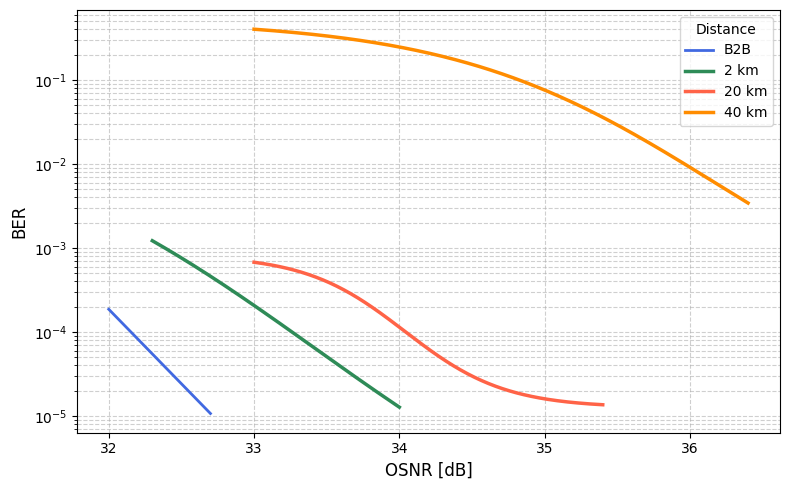

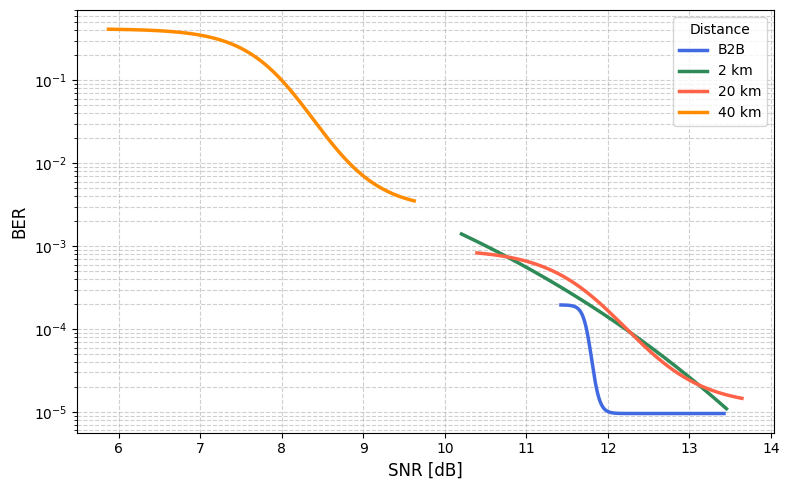

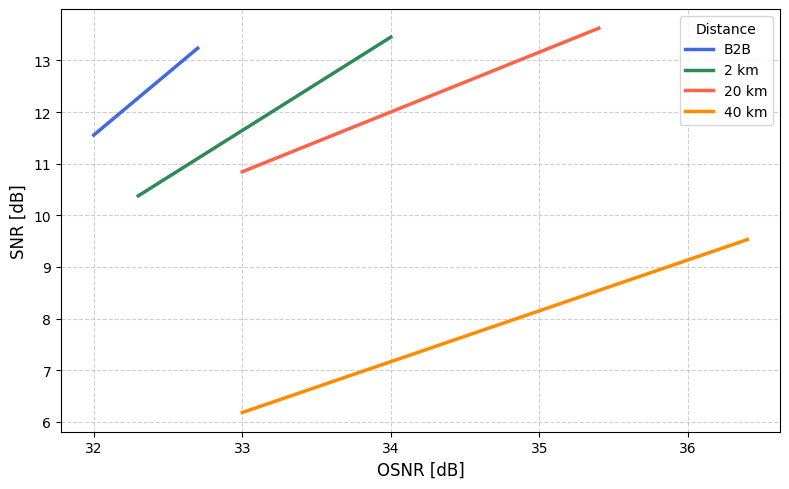

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress

# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

df = pd.read_csv("results_qpsk_dfb_extended_Prueba8_900.csv")

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS
# ─────────────────────────────────────────────

# 1. Outlier de 2 km (medición fallida)
#df_clean = df[~((df['distance_km'] == 2) &
 #               (df['osnr_db'] > 39) &
#                (df['ber'] > 0.01))]

# 2. BER = 0 globalmente
#df_clean = df_clean[df_clean['ber'] > 0]

# # 3. Outlier de 20 km (SNR aislado)
# df_clean = df_clean[~((df_clean['distance_km'] == 20) &
#                       (df_clean['snr_db'] < 6))]

# # 4. Outlier de 2 km  — OSNR=38.42, SNR=8.97 (muy bajo para ese OSNR)
# df_clean = df_clean[~((df_clean['distance_km'] == 2) &
#                       (df_clean['osnr_db'] > 38) &
#                       (df_clean['snr_db'] < 9.5))]

# # 5. Outlier de B2B — OSNR=39.01, SNR=10.76 (muy bajo para ese OSNR)
# df_clean = df_clean[~((df_clean['distance_km'] == 0) &
#                       (df_clean['osnr_db'] > 38.5) &
#                       (df_clean['snr_db'] < 11))]

# # 6. Outlier de 40 km — OSNR=39.57, SNR=9.75 (muy bajo para ese OSNR)
# df_clean = df_clean[~((df_clean['distance_km'] == 40) &
#                       (df_clean['osnr_db'] > 39) &
#                       (df_clean['snr_db'] < 10))]

print(f"Filas originales         : {len(df)}")
print(f"Filas después de limpieza: {len(df_clean)}")
print(f"Filas eliminadas         : {len(df) - len(df_clean)}")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col):
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values


def get_binned_curve(df, x_col, y_col, bin_width=0.25):
    df = df.copy()
    x_min = df[x_col].min()
    x_max = df[x_col].max()
    edges = np.arange(x_min, x_max + bin_width, bin_width)
    df['bin'] = pd.cut(df[x_col], bins=edges)
    grouped = df.groupby('bin', observed=True)[y_col].mean().reset_index()
    grouped[x_col] = grouped['bin'].apply(lambda b: b.mid)
    grouped = grouped.dropna(subset=[x_col, y_col])
    grouped = grouped[grouped[y_col] > 0]
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values.astype(float), grouped[y_col].values


def sigmoid_log(x, a, b, c, d):
    return a / (1 + np.exp(b * (x - c))) + d


def get_label(dist):
    if dist == 0:
        return "B2B"
    return f"{int(dist)} km"


COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS = sorted(df_clean['distance_km'].unique())


# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR
# ─────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo  = df_clean[df_clean['distance_km'] == dist]
    x, y   = get_mean_curve(grupo, 'osnr_db', 'ber')
    mask   = y > 0
    x_plot, y_plot = x[mask], y[mask]

    # ax1.semilogy(x_plot, y_plot, 'o', ...)   ← puntos eliminados

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax1.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs OSNR ({get_label(dist)}): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR
# ─────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo  = df_clean[df_clean['distance_km'] == dist]
    x_plot, y_plot = get_binned_curve(grupo, 'snr_db', 'ber', bin_width=0.25)

    # ax2.semilogy(x_plot, y_plot, 'o', ...)   ← puntos eliminados

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_snr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — SNR vs OSNR (promedio simple, con puntos)
# ─────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo    = df_clean[df_clean['distance_km'] == dist]
    df_grupo = grupo[['osnr_db', 'snr_db']].dropna()

    # Promedio simple de SNR por nivel de OSNR — correcto porque OSNR ya es discreto
    df_mean  = (df_grupo.groupby('osnr_db')['snr_db']
                        .mean().reset_index()
                        .sort_values('osnr_db'))

    x_raw = df_mean['osnr_db'].values   # OSNR en eje X
    y_raw = df_mean['snr_db'].values    # SNR en eje Y

 #   ax3.plot(x_raw, y_raw, 'o', color=color,
  #           markersize=4, alpha=0.15)

    slope, intercept, r_value, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=get_label(dist))

ax3.set_xlabel("OSNR [dB]", fontsize=12)
ax3.set_ylabel("SNR [dB]", fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("snr_vs_osnr_por_distancia.png", dpi=150)
plt.show()

### Graficas solapadas:


Prueba6 — Filas después de limpieza: 383
Prueba7 — Filas después de limpieza: 204


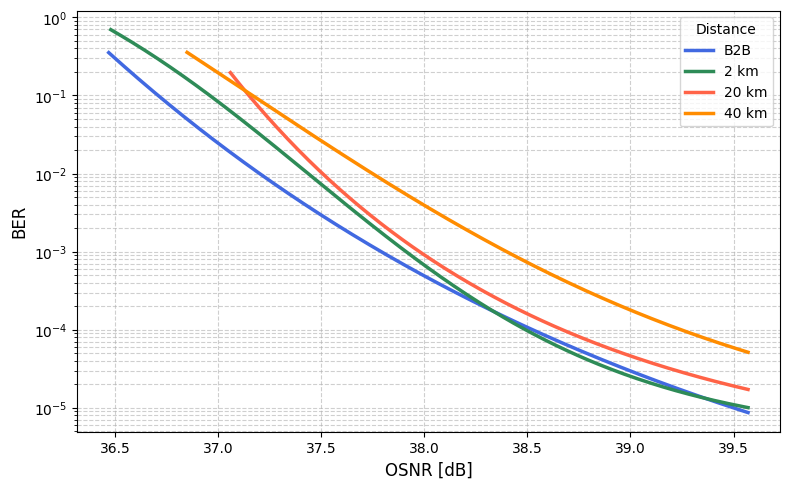

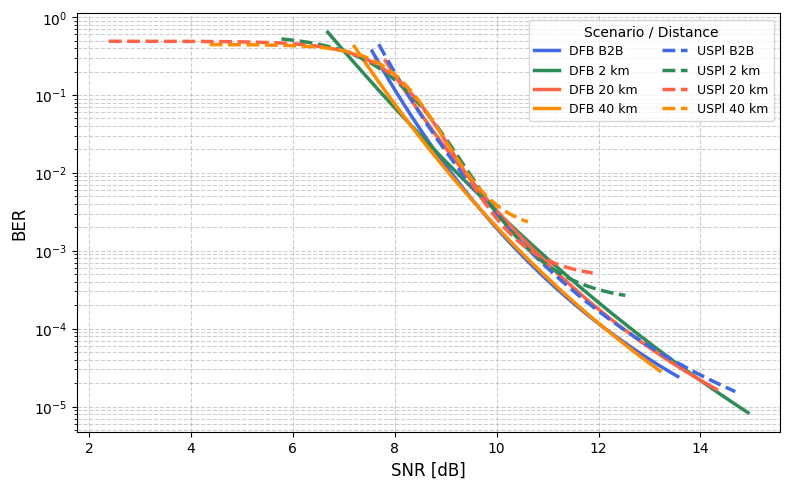

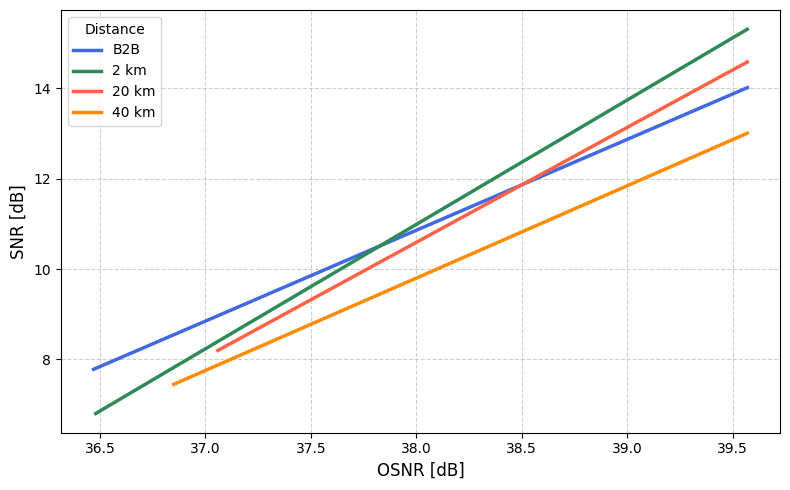

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress

# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

df = pd.read_csv("results_qpsk_dfb_extended_Prueba6.csv")
df7 = pd.read_csv("results_qpsk_dfb_extended_Prueba7.csv")

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS — Prueba 6
# ─────────────────────────────────────────────

df_clean = df[~((df['distance_km'] == 2) &
                (df['osnr_db'] > 39) &
                (df['ber'] > 0.01))]
df_clean = df_clean[df_clean['ber'] > 0]

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS — Prueba 7
# ─────────────────────────────────────────────

df7_clean = df7[~((df7['distance_km'] == 2) &
                  (df7['osnr_db'] > 39) &
                  (df7['ber'] > 0.01))]
df7_clean = df7_clean[df7_clean['ber'] > 0]

print(f"Prueba6 — Filas después de limpieza: {len(df_clean)}")
print(f"Prueba7 — Filas después de limpieza: {len(df7_clean)}")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col):
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values


def get_binned_curve(df, x_col, y_col, bin_width=0.25):
    df = df.copy()
    edges = np.arange(df[x_col].min(), df[x_col].max() + bin_width, bin_width)
    df['bin'] = pd.cut(df[x_col], bins=edges)
    grouped = df.groupby('bin', observed=True)[y_col].mean().reset_index()
    grouped[x_col] = grouped['bin'].apply(lambda b: b.mid)
    grouped = grouped.dropna(subset=[x_col, y_col])
    grouped = grouped[grouped[y_col] > 0]
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values.astype(float), grouped[y_col].values


def sigmoid_log(x, a, b, c, d):
    return a / (1 + np.exp(b * (x - c))) + d


def get_label(dist):
    return "B2B" if dist == 0 else f"{int(dist)} km"


COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS = sorted(df_clean['distance_km'].unique())


# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR  (solo Prueba 6)
# ─────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo       = df_clean[df_clean['distance_km'] == dist]
    x, y        = get_mean_curve(grupo, 'osnr_db', 'ber')
    x_plot, y_plot = x[y > 0], y[y > 0]

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax1.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs OSNR ({get_label(dist)}): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR  (Prueba 6 + Prueba 7)
# ─────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(8, 5))

# ── Prueba 6 ──────────────────────────────────
for dist, color in zip(DISTANCIAS, COLORS):
    grupo = df_clean[df_clean['distance_km'] == dist]
    x_plot, y_plot = get_binned_curve(grupo, 'snr_db', 'ber', bin_width=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"DFB {get_label(dist)}")
    except Exception as e:
        print(f"⚠️ P6 Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"DFB {get_label(dist)}")

# ── Prueba 7 ──────────────────────────────────
DISTANCIAS7 = sorted(df7_clean['distance_km'].unique())

for dist, color in zip(DISTANCIAS7, COLORS):
    grupo = df7_clean[df7_clean['distance_km'] == dist]
    x_plot, y_plot = get_binned_curve(grupo, 'snr_db', 'ber', bin_width=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '--', color=color,
                     linewidth=2.5, label=f"USPl {get_label(dist)}")
    except Exception as e:
        print(f"⚠️ P7 Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '--', color=color,
                     linewidth=2, label=f"USPl {get_label(dist)}")

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.legend(title="Scenario / Distance", fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("ber_vs_snr_comparacion.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — SNR vs OSNR  (solo Prueba 6)
# ─────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo   = df_clean[df_clean['distance_km'] == dist]
    df_mean = (grupo[['osnr_db', 'snr_db']].dropna()
               .groupby('osnr_db')['snr_db'].mean()
               .reset_index().sort_values('osnr_db'))

    x_raw = df_mean['osnr_db'].values
    y_raw = df_mean['snr_db'].values

    slope, intercept, _, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=get_label(dist))

ax3.set_xlabel("OSNR [dB]", fontsize=12)
ax3.set_ylabel("SNR [dB]", fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("snr_vs_osnr_por_distancia.png", dpi=150)
plt.show()

Prueba6 — Filas después de limpieza: 383
Prueba7 — Filas después de limpieza: 204


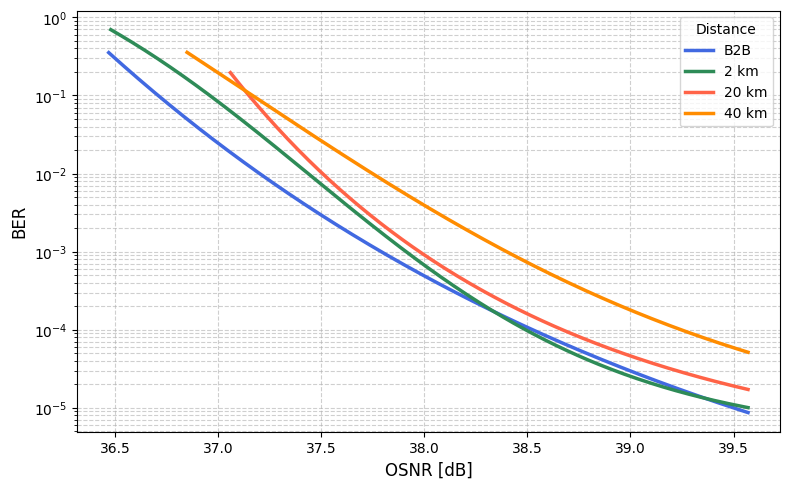

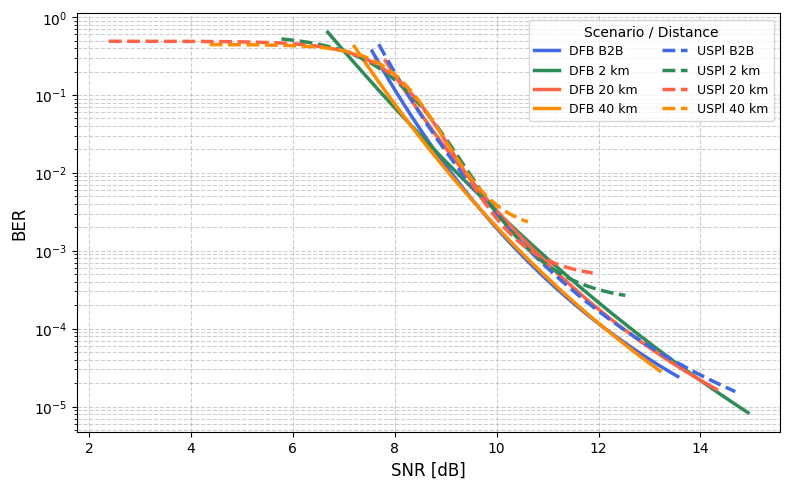

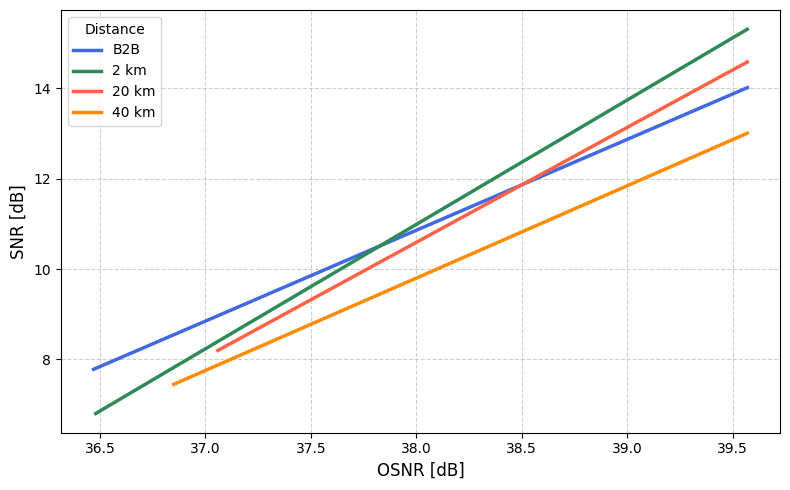

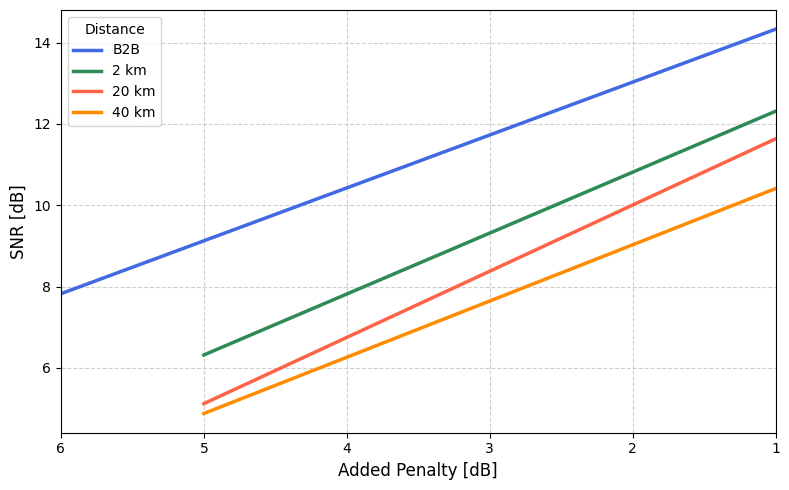

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress

# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

df = pd.read_csv("results_qpsk_dfb_extended_Prueba6.csv")
df7 = pd.read_csv("results_qpsk_dfb_extended_Prueba7.csv")

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS — Prueba 6
# ─────────────────────────────────────────────

df_clean = df[~((df['distance_km'] == 2) &
                (df['osnr_db'] > 39) &
                (df['ber'] > 0.01))]
df_clean = df_clean[df_clean['ber'] > 0]

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS — Prueba 7
# ─────────────────────────────────────────────

df7_clean = df7[~((df7['distance_km'] == 2) &
                  (df7['osnr_db'] > 39) &
                  (df7['ber'] > 0.01))]
df7_clean = df7_clean[df7_clean['ber'] > 0]

print(f"Prueba6 — Filas después de limpieza: {len(df_clean)}")
print(f"Prueba7 — Filas después de limpieza: {len(df7_clean)}")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col):
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values


def get_binned_curve(df, x_col, y_col, bin_width=0.25):
    df = df.copy()
    edges = np.arange(df[x_col].min(), df[x_col].max() + bin_width, bin_width)
    df['bin'] = pd.cut(df[x_col], bins=edges)
    grouped = df.groupby('bin', observed=True)[y_col].mean().reset_index()
    grouped[x_col] = grouped['bin'].apply(lambda b: b.mid)
    grouped = grouped.dropna(subset=[x_col, y_col])
    grouped = grouped[grouped[y_col] > 0]
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values.astype(float), grouped[y_col].values


def sigmoid_log(x, a, b, c, d):
    return a / (1 + np.exp(b * (x - c))) + d


def get_label(dist):
    return "B2B" if dist == 0 else f"{int(dist)} km"


COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS = sorted(df_clean['distance_km'].unique())


# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR  (solo Prueba 6)
# ─────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo       = df_clean[df_clean['distance_km'] == dist]
    x, y        = get_mean_curve(grupo, 'osnr_db', 'ber')
    x_plot, y_plot = x[y > 0], y[y > 0]

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax1.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs OSNR ({get_label(dist)}): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR  (Prueba 6 + Prueba 7)
# ─────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(8, 5))

# ── Prueba 6 ──────────────────────────────────
for dist, color in zip(DISTANCIAS, COLORS):
    grupo = df_clean[df_clean['distance_km'] == dist]
    x_plot, y_plot = get_binned_curve(grupo, 'snr_db', 'ber', bin_width=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"DFB {get_label(dist)}")
    except Exception as e:
        print(f"⚠️ P6 Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"DFB {get_label(dist)}")

# ── Prueba 7 ──────────────────────────────────
DISTANCIAS7 = sorted(df7_clean['distance_km'].unique())

for dist, color in zip(DISTANCIAS7, COLORS):
    grupo = df7_clean[df7_clean['distance_km'] == dist]
    x_plot, y_plot = get_binned_curve(grupo, 'snr_db', 'ber', bin_width=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '--', color=color,
                     linewidth=2.5, label=f"USPl {get_label(dist)}")
    except Exception as e:
        print(f"⚠️ P7 Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '--', color=color,
                     linewidth=2, label=f"USPl {get_label(dist)}")

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.legend(title="Scenario / Distance", fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("ber_vs_snr_comparacion.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — SNR vs OSNR  (solo Prueba 6 — DFB)
# ─────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo   = df_clean[df_clean['distance_km'] == dist]
    df_mean = (grupo[['osnr_db', 'snr_db']].dropna()
               .groupby('osnr_db')['snr_db'].mean()
               .reset_index().sort_values('osnr_db'))

    x_raw = df_mean['osnr_db'].values
    y_raw = df_mean['snr_db'].values

    slope, intercept, _, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=get_label(dist))

ax3.set_xlabel("OSNR [dB]", fontsize=12)
ax3.set_ylabel("SNR [dB]", fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("snr_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 4 — SNR vs Penalty (solo Prueba 7 — USPl)
# ─────────────────────────────────────────────

fig4, ax4 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS7, COLORS):
    grupo   = df7_clean[df7_clean['distance_km'] == dist]
    df_mean = (grupo[['osnr_db', 'snr_db']].dropna()
               .groupby('osnr_db')['snr_db'].mean()
               .reset_index().sort_values('osnr_db'))

    x_raw = df_mean['osnr_db'].values
    y_raw = df_mean['snr_db'].values

    slope, intercept, _, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax4.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=get_label(dist))

# Cambios solicitados para el eje X de la Prueba 7
ax4.set_xlabel("Added Penalty [dB]", fontsize=12)
ax4.set_ylabel("SNR [dB]", fontsize=12)
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend(title="Distance", fontsize=10)

# Forzar el orden invertido en el eje X de 6 a 1
ax4.set_xlim(6, 1)

plt.tight_layout()
plt.savefig("snr_vs_penalty_por_distancia.png", dpi=150)
plt.show()

Prueba6 — Filas después de limpieza: 383
Prueba7 — Filas después de limpieza: 204


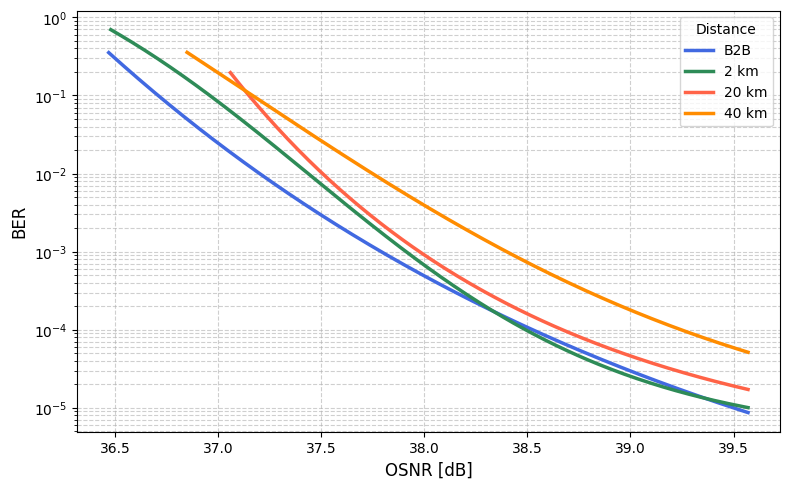

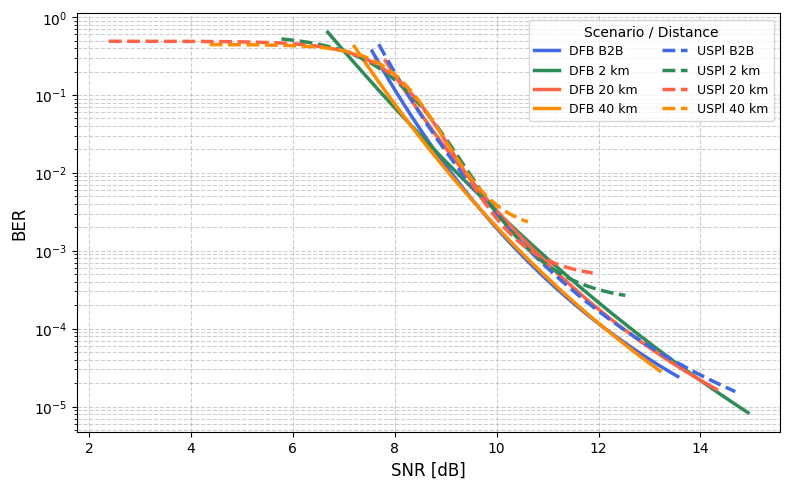

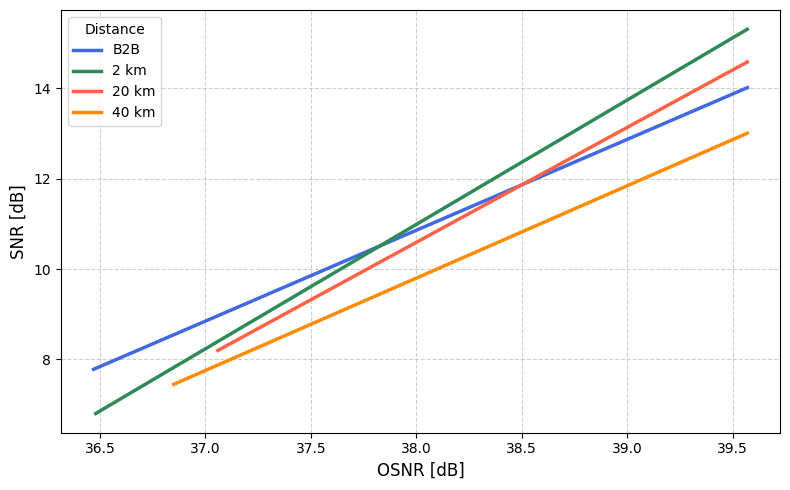

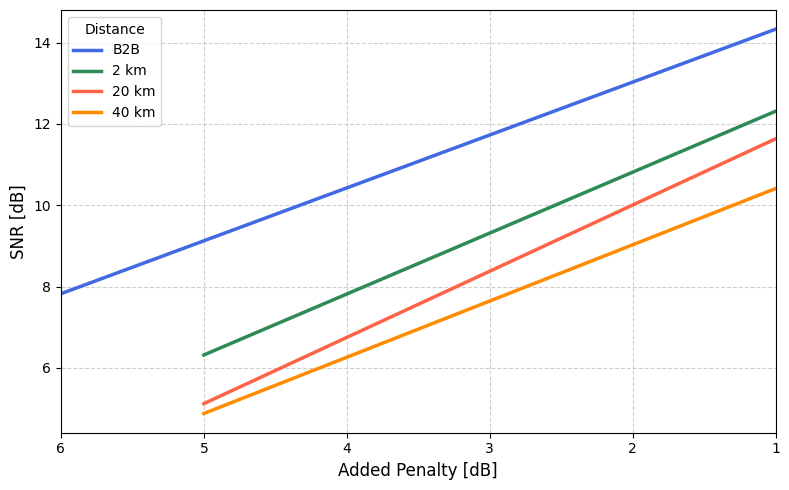

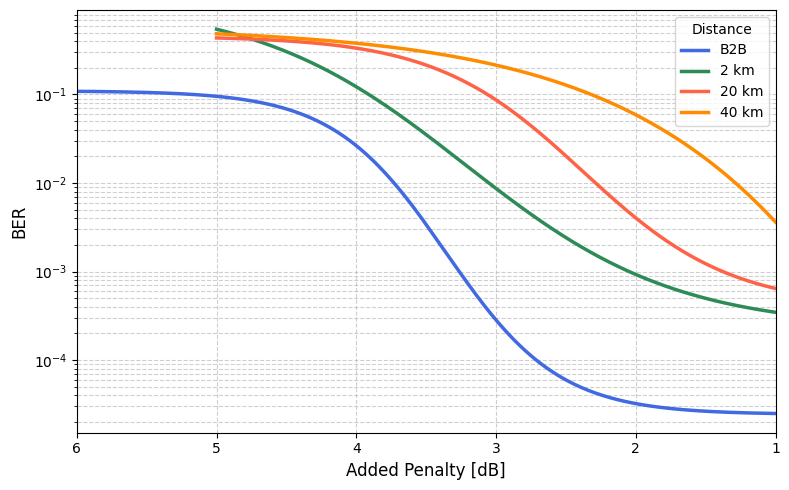

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress

# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

df = pd.read_csv("results_qpsk_dfb_extended_Prueba6.csv")
df7 = pd.read_csv("results_qpsk_dfb_extended_Prueba7.csv")

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS — Prueba 6
# ─────────────────────────────────────────────

df_clean = df[~((df['distance_km'] == 2) &
                (df['osnr_db'] > 39) &
                (df['ber'] > 0.01))]
df_clean = df_clean[df_clean['ber'] > 0]

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS — Prueba 7
# ─────────────────────────────────────────────

df7_clean = df7[~((df7['distance_km'] == 2) &
                  (df7['osnr_db'] > 39) &
                  (df7['ber'] > 0.01))]
df7_clean = df7_clean[df7_clean['ber'] > 0]

print(f"Prueba6 — Filas después de limpieza: {len(df_clean)}")
print(f"Prueba7 — Filas después de limpieza: {len(df7_clean)}")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col):
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values


def get_binned_curve(df, x_col, y_col, bin_width=0.25):
    df = df.copy()
    edges = np.arange(df[x_col].min(), df[x_col].max() + bin_width, bin_width)
    df['bin'] = pd.cut(df[x_col], bins=edges)
    grouped = df.groupby('bin', observed=True)[y_col].mean().reset_index()
    grouped[x_col] = grouped['bin'].apply(lambda b: b.mid)
    grouped = grouped.dropna(subset=[x_col, y_col])
    grouped = grouped[grouped[y_col] > 0]
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values.astype(float), grouped[y_col].values


def sigmoid_log(x, a, b, c, d):
    return a / (1 + np.exp(b * (x - c))) + d


def get_label(dist):
    return "B2B" if dist == 0 else f"{int(dist)} km"


COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS = sorted(df_clean['distance_km'].unique())


# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR  (solo Prueba 6)
# ─────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo       = df_clean[df_clean['distance_km'] == dist]
    x, y        = get_mean_curve(grupo, 'osnr_db', 'ber')
    x_plot, y_plot = x[y > 0], y[y > 0]

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax1.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs OSNR ({get_label(dist)}): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR  (Prueba 6 + Prueba 7)
# ─────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(8, 5))

# ── Prueba 6 ──────────────────────────────────
for dist, color in zip(DISTANCIAS, COLORS):
    grupo = df_clean[df_clean['distance_km'] == dist]
    x_plot, y_plot = get_binned_curve(grupo, 'snr_db', 'ber', bin_width=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"DFB {get_label(dist)}")
    except Exception as e:
        print(f"⚠️ P6 Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"DFB {get_label(dist)}")

# ── Prueba 7 ──────────────────────────────────
DISTANCIAS7 = sorted(df7_clean['distance_km'].unique())

for dist, color in zip(DISTANCIAS7, COLORS):
    grupo = df7_clean[df7_clean['distance_km'] == dist]
    x_plot, y_plot = get_binned_curve(grupo, 'snr_db', 'ber', bin_width=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '--', color=color,
                     linewidth=2.5, label=f"USPl {get_label(dist)}")
    except Exception as e:
        print(f"⚠️ P7 Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '--', color=color,
                     linewidth=2, label=f"USPl {get_label(dist)}")

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.legend(title="Scenario / Distance", fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("ber_vs_snr_comparacion.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — SNR vs OSNR  (solo Prueba 6 — DFB)
# ─────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo   = df_clean[df_clean['distance_km'] == dist]
    df_mean = (grupo[['osnr_db', 'snr_db']].dropna()
               .groupby('osnr_db')['snr_db'].mean()
               .reset_index().sort_values('osnr_db'))

    x_raw = df_mean['osnr_db'].values
    y_raw = df_mean['snr_db'].values

    slope, intercept, _, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=get_label(dist))

ax3.set_xlabel("OSNR [dB]", fontsize=12)
ax3.set_ylabel("SNR [dB]", fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("snr_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 4 — SNR vs Penalty (solo Prueba 7 — USPl)
# ─────────────────────────────────────────────

fig4, ax4 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS7, COLORS):
    grupo   = df7_clean[df7_clean['distance_km'] == dist]
    df_mean = (grupo[['osnr_db', 'snr_db']].dropna()
               .groupby('osnr_db')['snr_db'].mean()
               .reset_index().sort_values('osnr_db'))

    x_raw = df_mean['osnr_db'].values
    y_raw = df_mean['snr_db'].values

    slope, intercept, _, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax4.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=get_label(dist))

ax4.set_xlabel("Added Penalty [dB]", fontsize=12)
ax4.set_ylabel("SNR [dB]", fontsize=12)
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend(title="Distance", fontsize=10)

# Forzar el orden invertido en el eje X de 6 a 1
ax4.set_xlim(6, 1)

plt.tight_layout()
plt.savefig("snr_vs_penalty_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 5 — BER vs Penalty (solo Prueba 7 — USPl)
# ─────────────────────────────────────────────

fig5, ax5 = plt.subplots(figsize=(8, 5))

# Corregido: Se utiliza df7_clean y DISTANCIAS7 para la Prueba 7
for dist, color in zip(DISTANCIAS7, COLORS):
    grupo       = df7_clean[df7_clean['distance_km'] == dist]
    x, y        = get_mean_curve(grupo, 'osnr_db', 'ber')
    x_plot, y_plot = x[y > 0], y[y > 0]

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax5.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs Penalty ({get_label(dist)}): {e}")
        ax5.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

# Cambios solicitados para el eje X de la Prueba 7 en BER
ax5.set_xlabel("Added Penalty [dB]", fontsize=12)
ax5.set_ylabel("BER", fontsize=12)
ax5.grid(True, which='both', linestyle='--', alpha=0.6)
ax5.legend(title="Distance", fontsize=10)

# Forzar el orden invertido en el eje X de 6 a 1
ax5.set_xlim(6, 1)

plt.tight_layout()
plt.savefig("ber_vs_penalty_por_distancia.png", dpi=150)
plt.show()

### Graficas con puntos:

Filas originales         : 211
Filas después de limpieza: 211
Filas eliminadas         : 0


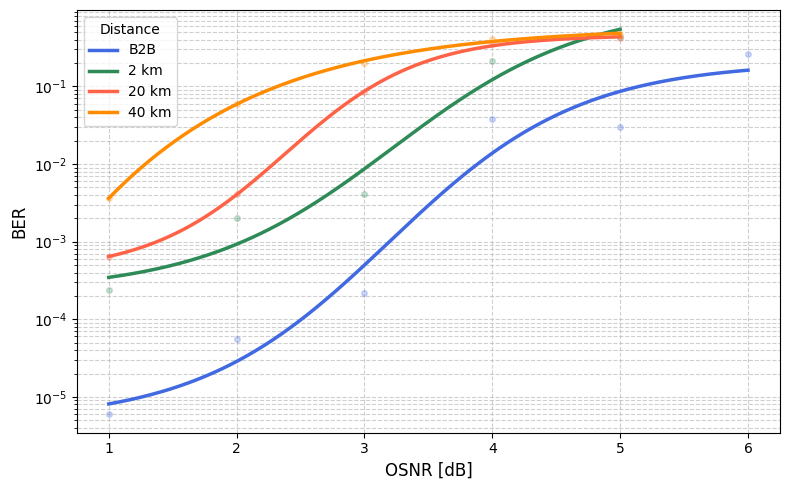

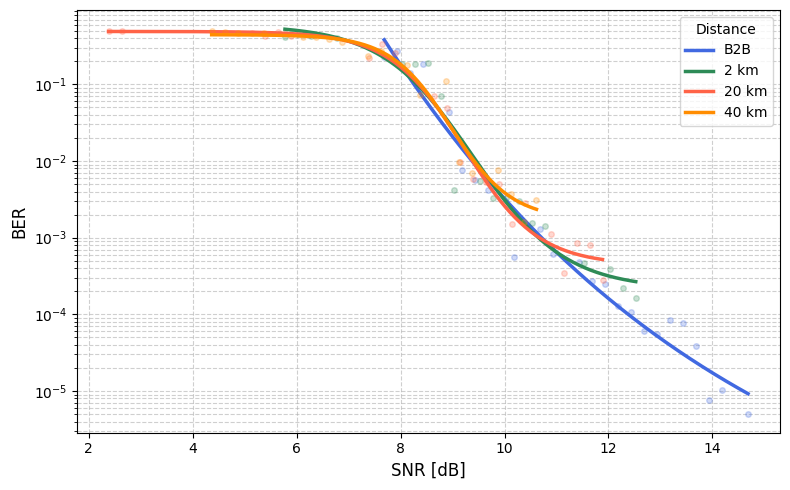

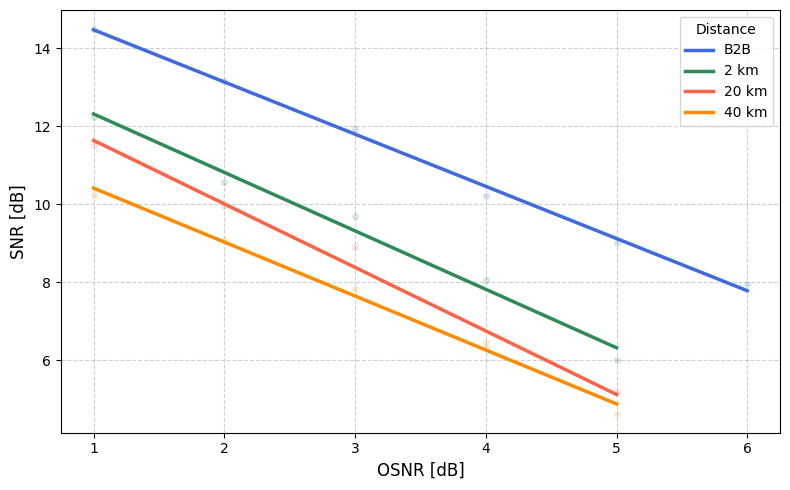

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress

# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

df = pd.read_csv("results_qpsk_dfb_extended_Prueba7.csv")

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS
# ─────────────────────────────────────────────

# 1. Outlier de 2 km (medición fallida)
df_clean = df[~((df['distance_km'] == 2) &
                (df['osnr_db'] > 39) &
                (df['ber'] > 0.01))]

# 2. BER = 0 globalmente
#df_clean = df_clean[df_clean['ber'] > 0]

# # 3. Outlier de 20 km (SNR aislado)
# df_clean = df_clean[~((df_clean['distance_km'] == 20) &
#                       (df_clean['snr_db'] < 6))]

# # 4. Outlier de 2 km  — OSNR=38.42, SNR=8.97 (muy bajo para ese OSNR)
# df_clean = df_clean[~((df_clean['distance_km'] == 2) &
#                       (df_clean['osnr_db'] > 38) &
#                       (df_clean['snr_db'] < 9.5))]

# # 5. Outlier de B2B — OSNR=39.01, SNR=10.76 (muy bajo para ese OSNR)
# df_clean = df_clean[~((df_clean['distance_km'] == 0) &
#                       (df_clean['osnr_db'] > 38.5) &
#                       (df_clean['snr_db'] < 11))]

# # 6. Outlier de 40 km — OSNR=39.57, SNR=9.75 (muy bajo para ese OSNR)
# df_clean = df_clean[~((df_clean['distance_km'] == 40) &
#                       (df_clean['osnr_db'] > 39) &
#                       (df_clean['snr_db'] < 10))]

print(f"Filas originales         : {len(df)}")
print(f"Filas después de limpieza: {len(df_clean)}")
print(f"Filas eliminadas         : {len(df) - len(df_clean)}")
# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col):
    """Promedio simple agrupado por x_col — usado para OSNR (ya discreto)"""
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values


def get_binned_curve(df, x_col, y_col, bin_width=0.25):
    """
    Divide el eje X en bins de ancho fijo y promedia el BER dentro de cada bin.
    Así cada intervalo tiene el mismo peso estadístico sin importar
    cuántos puntos caigan en él.

    Pasos:
      1. Calcula los bordes de los bins desde min hasta max del eje X
      2. Asigna cada fila al bin correspondiente con pd.cut()
      3. Promedia el BER dentro de cada bin
      4. Usa el centro del bin como valor de X representativo

    bin_width=0.25 → bins de 0.25 dB de ancho
    """
    df = df.copy()

    x_min = df[x_col].min()
    x_max = df[x_col].max()

    # Bordes de los bins: de x_min a x_max en pasos de bin_width
    edges = np.arange(x_min, x_max + bin_width, bin_width)

    # Asigna cada punto a su bin
    df['bin'] = pd.cut(df[x_col], bins=edges)

    # Promedia BER por bin — cada bin pesa igual independiente de cuántos puntos tenga
    grouped = df.groupby('bin', observed=True)[y_col].mean().reset_index()

    # Centro del bin como valor representativo de X
    grouped[x_col] = grouped['bin'].apply(lambda b: b.mid)

    # Elimina bins vacíos o con BER=0
    grouped = grouped.dropna(subset=[x_col, y_col])
    grouped = grouped[grouped[y_col] > 0]
    grouped = grouped.sort_values(x_col)

    return grouped[x_col].values.astype(float), grouped[y_col].values


def sigmoid_log(x, a, b, c, d):
    return a / (1 + np.exp(b * (x - c))) + d


def get_label(dist):
    if dist == 0:
        return "B2B"
    return f"{int(dist)} km"


COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS = sorted(df_clean['distance_km'].unique())


# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR (sin cambio, promedio simple)
# ─────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo  = df_clean[df_clean['distance_km'] == dist]
    x, y   = get_mean_curve(grupo, 'osnr_db', 'ber')
    mask   = y > 0
    x_plot, y_plot = x[mask], y[mask]

    ax1.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax1.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs OSNR ({get_label(dist)}): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR (con binning de 0.25 dB)
# ─────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo  = df_clean[df_clean['distance_km'] == dist]

    # Binning de 0.25 dB — cada bin pesa igual
    x_plot, y_plot = get_binned_curve(grupo, 'snr_db', 'ber', bin_width=0.25)

    # Puntos binneados (uno por bin)
    ax2.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_snr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — SNR vs OSNR (promedio simple, con puntos)
# ─────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo    = df_clean[df_clean['distance_km'] == dist]
    df_grupo = grupo[['osnr_db', 'snr_db']].dropna()

    # Promedio simple de SNR por nivel de OSNR — correcto porque OSNR ya es discreto
    df_mean  = (df_grupo.groupby('osnr_db')['snr_db']
                        .mean().reset_index()
                        .sort_values('osnr_db'))

    x_raw = df_mean['osnr_db'].values   # OSNR en eje X
    y_raw = df_mean['snr_db'].values    # SNR en eje Y

    ax3.plot(x_raw, y_raw, 'o', color=color,
           markersize=4, alpha=0.15)

    slope, intercept, r_value, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=get_label(dist))

ax3.set_xlabel("OSNR [dB]", fontsize=12)
ax3.set_ylabel("SNR [dB]", fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("snr_vs_osnr_por_distancia.png", dpi=150)
plt.show()

### Gráfica por promedio

Filas originales : 302
Filas después de limpieza: 159
Filas eliminadas : 143
⚠️ Fitting BER vs OSNR (0 km): The number of func parameters=4 must not exceed the number of data points=2


/tmp/ipykernel_3990/1951643159.py:65: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid_log, x_plot, log_y,


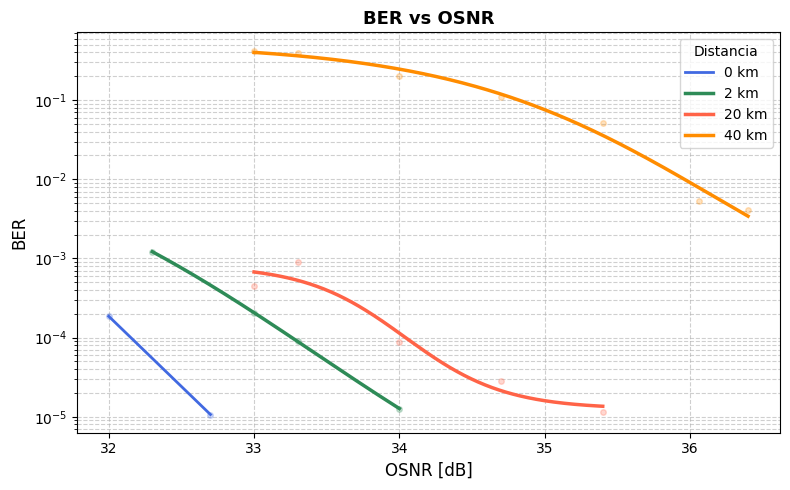

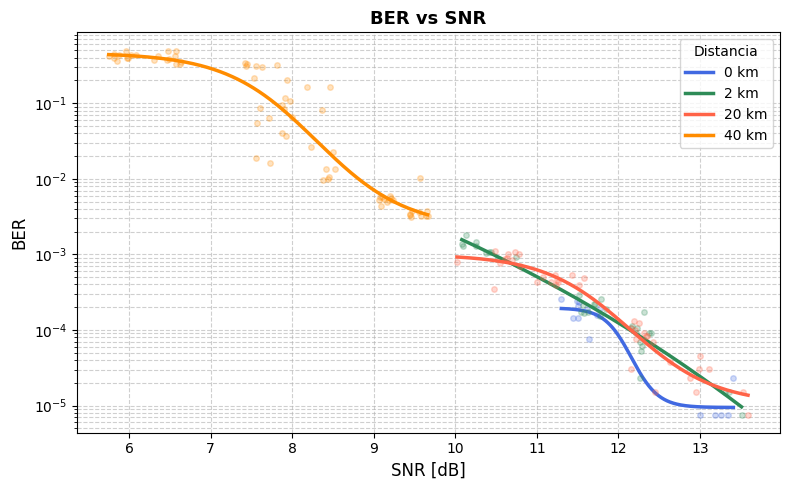

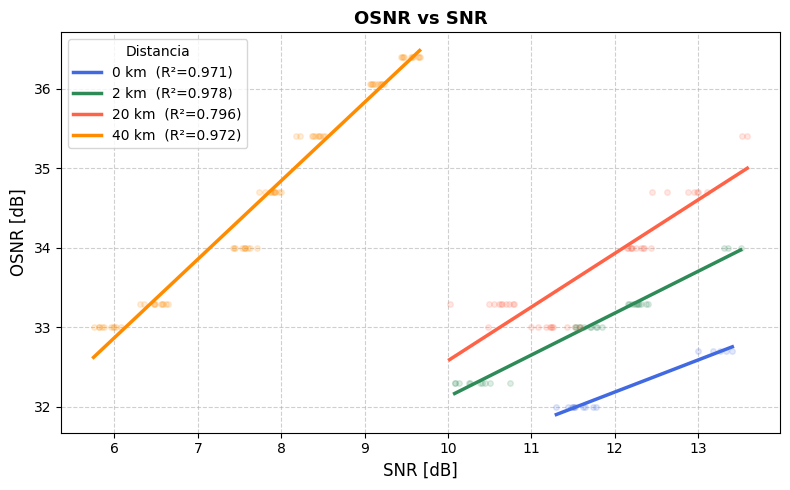

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress

# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

df = pd.read_csv("results_qpsk_dfb_extended_Prueba8_900.csv")

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS
# ─────────────────────────────────────────────

# 1. Eliminar outlier de 2 km (OSNR alto pero BER imposible)
#df_clean = df[~((df['distance_km'] == 2) &
#                (df['osnr_db'] > 39) &
#                (df['ber'] > 0.01))]

# 2. Eliminar BER = 0 globalmente (artefacto estadístico)
#df_clean = df_clean[df_clean['ber'] > 0]

print(f"Filas originales : {len(df)}")
print(f"Filas después de limpieza: {len(df_clean)}")
print(f"Filas eliminadas : {len(df) - len(df_clean)}")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col):
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values

def sigmoid_log(x, a, b, c, d):
    return a / (1 + np.exp(b * (x - c))) + d

COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS = sorted(df_clean['distance_km'].unique())


# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR por distancia
# ─────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo  = df_clean[df_clean['distance_km'] == dist]
    x, y   = get_mean_curve(grupo, 'osnr_db', 'ber')
    mask   = y > 0
    x_plot, y_plot = x[mask], y[mask]

    # Puntos crudos con baja opacidad
    ax1.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    # Fitting sigmoide en escala log
    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax1.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"{int(dist)} km")
    except Exception as e:
        print(f"⚠️ Fitting BER vs OSNR ({int(dist)} km): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"{int(dist)} km")

ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.set_title("BER vs OSNR", fontsize=13, fontweight='bold')
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR por distancia
# ─────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo  = df_clean[df_clean['distance_km'] == dist]
    x, y   = get_mean_curve(grupo, 'snr_db', 'ber')
    mask   = y > 0
    x_plot, y_plot = x[mask], y[mask]

    # Puntos crudos con baja opacidad
    ax2.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    # Fitting sigmoide en escala log
    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"{int(dist)} km")
    except Exception as e:
        print(f"⚠️ Fitting BER vs SNR ({int(dist)} km): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"{int(dist)} km")

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.set_title("BER vs SNR", fontsize=13, fontweight='bold')
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_snr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — OSNR vs SNR por distancia
# ─────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo    = df_clean[df_clean['distance_km'] == dist]
    df_grupo = grupo[['osnr_db', 'snr_db']].dropna()

    df_mean  = (df_grupo.groupby('snr_db')['osnr_db']
                        .mean().reset_index()
                        .sort_values('snr_db'))
    x_raw = df_mean['snr_db'].values
    y_raw = df_mean['osnr_db'].values

    # Puntos crudos con baja opacidad
    ax3.plot(x_raw, y_raw, 'o', color=color,
             markersize=4, alpha=0.15)

    # Regresión lineal
    slope, intercept, r_value, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=f"{int(dist)} km  (R²={r_value**2:.3f})")

ax3.set_xlabel("SNR [dB]", fontsize=12)
ax3.set_ylabel("OSNR [dB]", fontsize=12)
ax3.set_title("OSNR vs SNR", fontsize=13, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("osnr_vs_snr_por_distancia.png", dpi=150)
plt.show()


### Gráfica con EVM:

Filas después de limpieza: 292


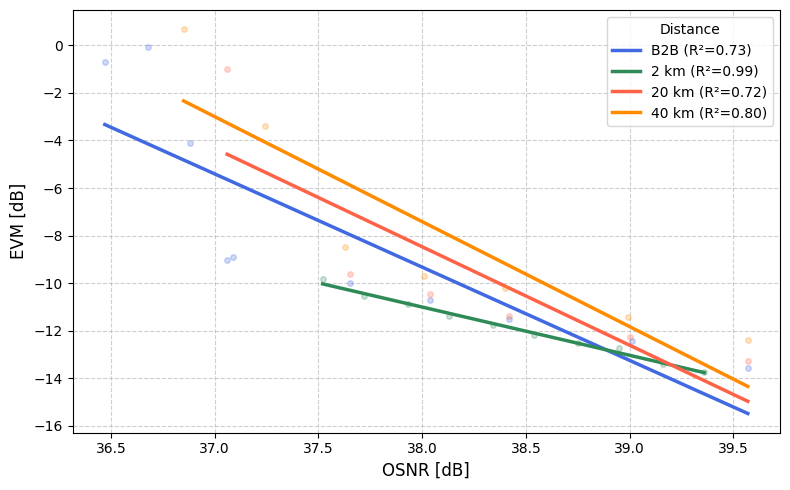

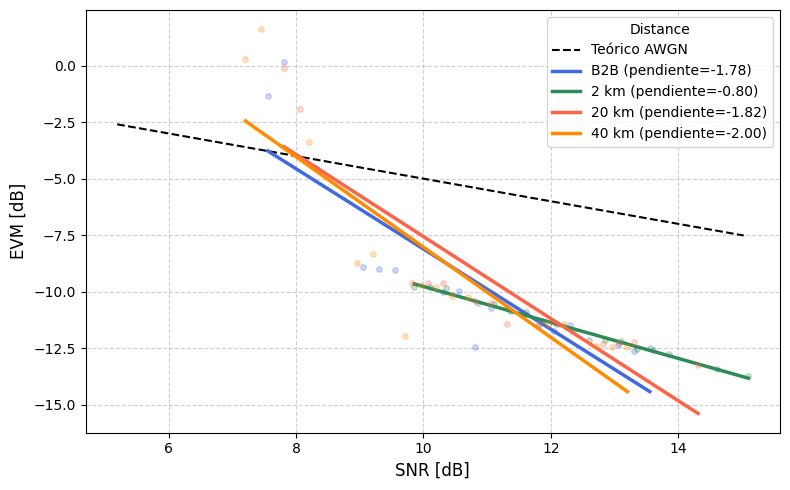

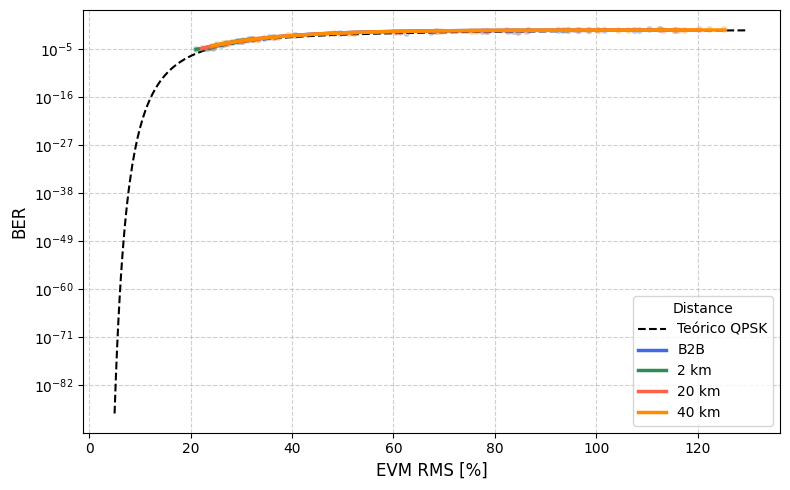

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
from scipy.special import erfc

# ─────────────────────────────────────────────
# CARGA Y LIMPIEZA  (igual que Prueba4)
# ─────────────────────────────────────────────

df = pd.read_csv("results_qpsk_dfb_extended_Prueba5.csv")

# 1. Outlier de 2 km (medición fallida)
df_clean = df[~((df['distance_km'] == 2) &
                (df['osnr_db'] > 39) &
                (df['ber'] > 0.01))]
# 2. BER = 0 globalmente
df_clean = df_clean[df_clean['ber'] > 0]
# 3. EVM = 0 o negativa
df_clean = df_clean[df_clean['evm_rms_pct'] > 0]

print(f"Filas después de limpieza: {len(df_clean)}")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES  (igual que antes)
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col):
    """Promedio simple agrupado por x_col — para OSNR (ya discreto)."""
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values


def get_binned_curve(df, x_col, y_col, bin_width=0.25, filter_positive=True):
    """Bins de ancho fijo sobre eje X, promedio de y dentro de cada bin.
    filter_positive=False para columnas como evm_db que pueden ser negativas."""
    df = df.copy()
    edges = np.arange(df[x_col].min(), df[x_col].max() + bin_width, bin_width)
    df['bin'] = pd.cut(df[x_col], bins=edges)
    grouped = df.groupby('bin', observed=True)[y_col].mean().reset_index()
    grouped[x_col] = grouped['bin'].apply(lambda b: b.mid)
    grouped = grouped.dropna(subset=[x_col, y_col])
    if filter_positive:
        grouped = grouped[grouped[y_col] > 0]
    return grouped[x_col].values.astype(float), grouped[y_col].values


def sigmoid_log(x, a, b, c, d):
    return a / (1 + np.exp(b * (x - c))) + d


def get_label(dist):
    return "B2B" if dist == 0 else f"{int(dist)} km"


COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS = sorted(df_clean['distance_km'].unique())


# ─────────────────────────────────────────────
# GRÁFICA 4 — EVM [dB] vs OSNR [dB]
# ─────────────────────────────────────────────
# Ambos ejes en dB → relación lineal esperada.
# Se usa promedio simple porque OSNR ya es discreto (igual que BER vs OSNR).
# ─────────────────────────────────────────────

fig4, ax4 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo = df_clean[df_clean['distance_km'] == dist]
    x, y  = get_mean_curve(grupo, 'osnr_db', 'evm_db')

    if len(x) < 2:
        print(f"⚠️ {get_label(dist)}: datos insuficientes para EVM vs OSNR")
        continue

    ax4.plot(x, y, 'o', color=color, markersize=4, alpha=0.25)

    # Regresión lineal — relación EVM(dB) vs OSNR(dB) es casi lineal
    slope, intercept, r_value, _, _ = linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 300)
    y_fit = slope * x_fit + intercept

    ax4.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=f"{get_label(dist)} (R²={r_value**2:.2f})")

ax4.set_xlabel("OSNR [dB]", fontsize=12)
ax4.set_ylabel("EVM [dB]", fontsize=12)
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("evm_db_vs_osnr.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 5 — EVM [dB] vs SNR [dB]
# ─────────────────────────────────────────────
# Ambos ejes en dB. Relación teórica para AWGN puro:
#   EVM_dB ≈ -SNR_dB / 2
# Se usa binning de 0.25 dB sobre SNR (igual que BER vs SNR).
# ─────────────────────────────────────────────

fig5, ax5 = plt.subplots(figsize=(8, 5))

# Curva teórica AWGN (independiente de distancia)
snr_teo  = np.linspace(df_clean['snr_db'].min(), df_clean['snr_db'].max(), 300)
evm_teo  = -snr_teo / 2   # EVM_dB = -SNR_dB/2 para AWGN puro
ax5.plot(snr_teo, evm_teo, 'k--', linewidth=1.5, label="Teórico AWGN")

for dist, color in zip(DISTANCIAS, COLORS):
    grupo = df_clean[df_clean['distance_km'] == dist]
    # filter_positive=False porque evm_db puede ser negativo (señal buena)
    x, y  = get_binned_curve(grupo, 'snr_db', 'evm_db', bin_width=0.25,
                             filter_positive=False)

    if len(x) < 2:
        print(f"⚠️ {get_label(dist)}: datos insuficientes para EVM vs SNR")
        continue

    ax5.plot(x, y, 'o', color=color, markersize=4, alpha=0.25)

    slope, intercept, r_value, _, _ = linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 300)
    y_fit = slope * x_fit + intercept

    ax5.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=f"{get_label(dist)} (pendiente={slope:.2f})")

ax5.set_xlabel("SNR [dB]", fontsize=12)
ax5.set_ylabel("EVM [dB]", fontsize=12)
ax5.grid(True, linestyle='--', alpha=0.6)
ax5.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("evm_db_vs_snr.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 6 — BER vs EVM [%]
# ─────────────────────────────────────────────
# Eje Y en escala logarítmica (semilogy).
# Se usa binning de 1% sobre EVM_rms_pct para promediar BER.
# Curva teórica QPSK:  BER = 0.5 * erfc(1 / (EVM * sqrt(2)))
# ─────────────────────────────────────────────

fig6, ax6 = plt.subplots(figsize=(8, 5))

# Curva teórica QPSK
evm_teo_pct = np.linspace(5, 130, 500)
ber_teo     = 0.5 * erfc(1.0 / (evm_teo_pct / 100 * np.sqrt(2)))
ax6.semilogy(evm_teo_pct, ber_teo, 'k--', linewidth=1.5, label="Teórico QPSK")

for dist, color in zip(DISTANCIAS, COLORS):
    grupo = df_clean[df_clean['distance_km'] == dist]
    x, y  = get_binned_curve(grupo, 'evm_rms_pct', 'ber', bin_width=1.0)

    ax6.semilogy(x, y, 'o', color=color, markersize=4, alpha=0.25)

    # Fitting sigmoide en log igual que BER vs OSNR/SNR
    try:
        log_y = np.log10(y)
        popt, _ = curve_fit(sigmoid_log, x, log_y,
                            p0=[-3, 0.05, np.median(x), -3],
                            maxfev=10000)
        x_fit = np.linspace(x.min(), x.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax6.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs EVM ({get_label(dist)}): {e}")
        ax6.semilogy(x, y, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax6.set_xlabel("EVM RMS [%]", fontsize=12)
ax6.set_ylabel("BER", fontsize=12)
ax6.grid(True, which='both', linestyle='--', alpha=0.6)
ax6.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_evm_rms.png", dpi=150)
plt.show()

### Grafica con el MENOR

Filas originales         : 330
Filas después de limpieza: 303
Filas eliminadas         : 27


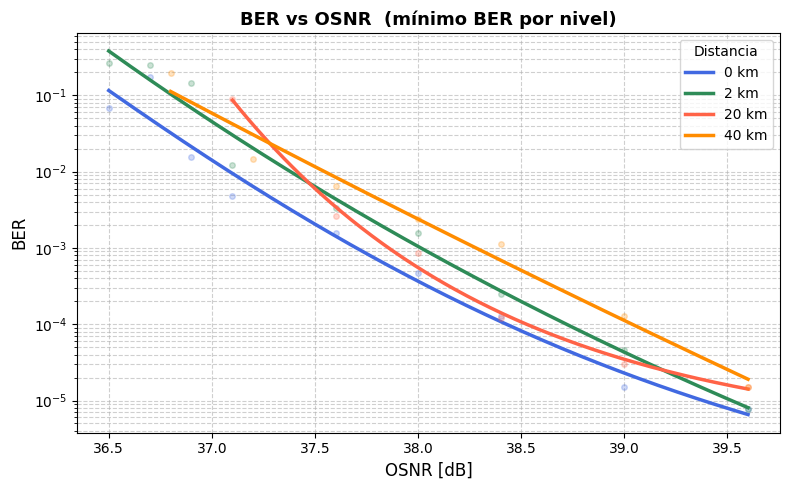

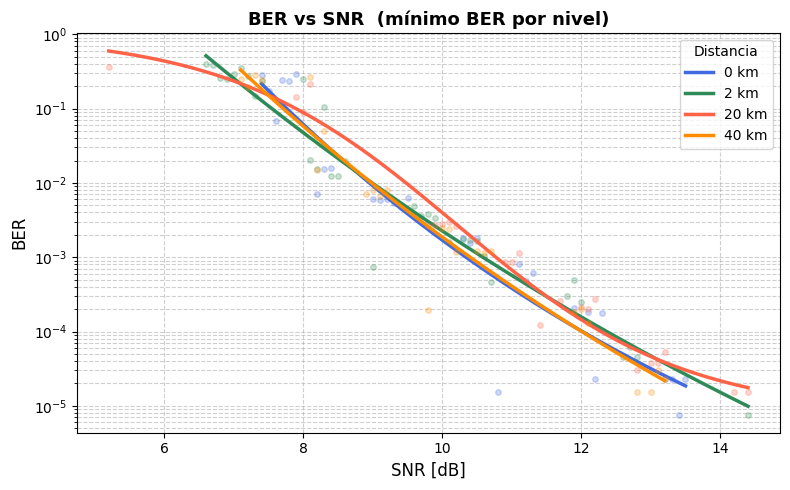

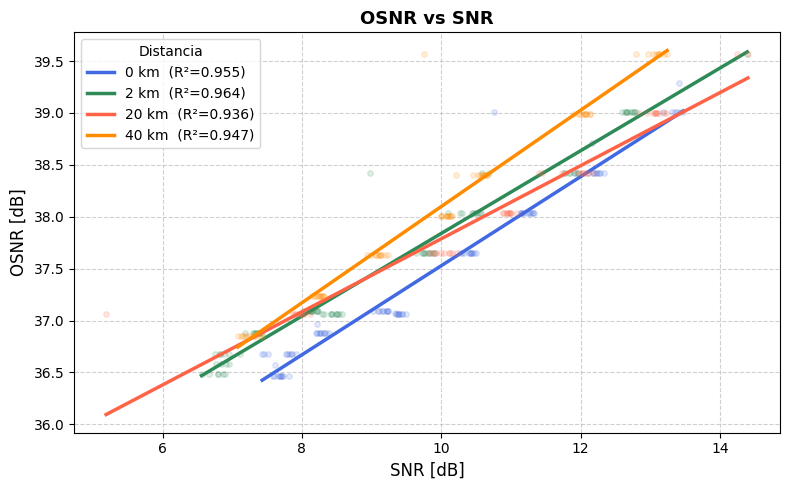

In [ ]:
import numpy as np              # Operaciones matemáticas: log10, exp, linspace, etc.
import pandas as pd             # Manejo del CSV como tabla (DataFrame)
import matplotlib.pyplot as plt # Crear y mostrar las gráficas
from scipy.optimize import curve_fit   # Ajuste de curva sigmoide (no lineal)
from scipy.interpolate import interp1d # Interpolación (importada pero no se usa activamente)
from scipy.stats import linregress     # Regresión lineal para Gráfica 3 (OSNR vs SNR)

# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

df = pd.read_csv("results_qpsk_dfb_extended_Prueba3.csv") # Lee el CSV y lo guarda como tabla df
                                                           # Cada fila = una simulación individual

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS
# ─────────────────────────────────────────────

# El operador ~ significa NOT — elimina filas donde se cumplan las 3 condiciones a la vez:
# distancia == 2 km  AND  osnr > 39 dB  AND  ber > 0.01
# Ese era el outlier físicamente imposible (OSNR=39.57, BER=0.216)
df_clean = df[~((df['distance_km'] == 2) &
                (df['osnr_db'] > 39) &
                (df['ber'] > 0.01))]

# Elimina filas donde BER = 0 exactamente
# BER=0 es un artefacto: significa que no hubo errores en esa ventana de simulación
# pero no es un valor físico real. Además log10(0) = -inf y rompería el fitting
df_clean = df_clean[df_clean['ber'] > 0]

# Imprime cuántas filas se eliminaron para verificar que la limpieza fue correcta
print(f"Filas originales         : {len(df)}")
print(f"Filas después de limpieza: {len(df_clean)}")
print(f"Filas eliminadas         : {len(df) - len(df_clean)}")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────



def get_min_curve(df, x_col, y_col, decimals=1):
    df = df.copy()
    df[x_col] = df[x_col].round(decimals)  # Redondea x para agrupar valores continuos cercanos
                                            # decimals=1 → 8.234, 8.241, 8.256 → todos a 8.2
    grouped = df.groupby(x_col)[y_col].min().reset_index()  # BER mínimo por nivel redondeado
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values


#def get_min_curve(df, x_col, y_col):
    # Agrupa todas las filas que tienen el mismo valor de x_col (ej: mismo OSNR)
    # y se queda con el BER MÍNIMO de ese grupo — el mejor caso medido en ese nivel
#    grouped = df.groupby(x_col)[y_col].min().reset_index()  # .min() = menor BER por nivel
#   grouped = grouped.sort_values(x_col) # Ordena de menor a mayor OSNR/SNR para que la curva sea continua
 #   return grouped[x_col].values, grouped[y_col].values # Devuelve dos arrays: x e y

def sigmoid_log(x, a, b, c, d):
    # Modelo sigmoide que se aplica sobre log10(BER), no sobre BER directamente
    # a → amplitud: cuántas décadas cae la BER (típicamente -5 a -7)
    # b → pendiente: qué tan rápido cae (mayor b = caída más abrupta)
    # c → punto de inflexión: OSNR/SNR donde la caída es más rápida
    # d → piso asintótico: BER mínima alcanzable (en log10)
    return a / (1 + np.exp(b * (x - c))) + d

COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange'] # Un color por distancia
DISTANCIAS = sorted(df_clean['distance_km'].unique())          # [0, 2, 20, 40] km ordenados

# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR
# ─────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(8, 5)) # Crea figura de 8x5 pulgadas

for dist, color in zip(DISTANCIAS, COLORS): # Itera: (0km, azul), (2km, verde), etc.

    grupo  = df_clean[df_clean['distance_km'] == dist] # Filtra solo las filas de esta distancia
    x, y   = get_min_curve(grupo, 'osnr_db', 'ber')    # Obtiene el BER mínimo por nivel de OSNR
    mask   = y > 0                                      # Máscara para excluir cualquier BER=0 residual
    x_plot, y_plot = x[mask], y[mask]                  # Aplica la máscara a x e y

    # Grafica los puntos del mínimo BER con baja opacidad (se ven como puntos de fondo)
    ax1.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25) # alpha=0.25 = 25% de opacidad = semitransparente

    # ── FITTING ──────────────────────────────────────────────────────
    try:
        log_y = np.log10(y_plot) # Transforma BER a escala log10 para que el fitting tenga igual
                                  # peso en todos los órdenes de magnitud (de 10⁻¹ a 10⁻⁶)

        popt, _ = curve_fit(sigmoid_log,        # Función a ajustar
                            x_plot, log_y,      # Datos: x=OSNR, y=log10(BER mínimo)
                            p0=[-6, 2, np.median(x_plot), -6], # Valores iniciales de a,b,c,d
                            maxfev=10000)        # Máximo 10000 iteraciones antes de rendirse

        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300) # 300 puntos x equiespaciados para curva suave
        y_fit = 10 ** sigmoid_log(x_fit, *popt)              # Evalúa la sigmoide y convierte de log10 a lineal
                                                              # *popt desempaca [a, b, c, d]

        ax1.semilogy(x_fit, y_fit, '-', color=color,         # Grafica la curva ajustada (línea sólida)
                     linewidth=2.5, label=f"{int(dist)} km") # con el label para la leyenda

    except Exception as e: # Si el fitting falla (no converge), avisa y grafica los puntos directamente
        print(f"⚠️ Fitting BER vs OSNR ({int(dist)} km): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"{int(dist)} km")

# Etiquetas y formato de la gráfica
ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.set_title("BER vs OSNR  (mínimo BER por nivel)", fontsize=13, fontweight='bold')
ax1.grid(True, which='both', linestyle='--', alpha=0.6) # Grid en líneas principales Y secundarias (which='both')
ax1.legend(title="Distancia", fontsize=10)
plt.tight_layout()                                       # Ajusta márgenes automáticamente
plt.savefig("ber_vs_osnr_min.png", dpi=150)             # Guarda en disco a 150 DPI
plt.show()                                               # Muestra en pantalla


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR
# ─────────────────────────────────────────────
# Exactamente el mismo procedimiento que Gráfica 1
# La única diferencia es que el eje X es snr_db en vez de osnr_db

fig2, ax2 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):

    grupo  = df_clean[df_clean['distance_km'] == dist]
    x, y   = get_min_curve(grupo, 'snr_db', 'ber')  # ← snr_db en vez de osnr_db
    mask   = y > 0
    x_plot, y_plot = x[mask], y[mask]

    ax2.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6], # p0[1]=1 en vez de 2 porque
                            maxfev=10000)                       # la pendiente vs SNR es más suave
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"{int(dist)} km")
    except Exception as e:
        print(f"⚠️ Fitting BER vs SNR ({int(dist)} km): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"{int(dist)} km")

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.set_title("BER vs SNR  (mínimo BER por nivel)", fontsize=13, fontweight='bold')
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_snr_min.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — OSNR vs SNR
# ─────────────────────────────────────────────
# Esta gráfica NO usa mínimo sino promedio, porque aquí no se grafica BER
# sino la relación entre dos métricas continuas (OSNR y SNR)
# donde el promedio es el estadístico correcto

fig3, ax3 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):

    grupo    = df_clean[df_clean['distance_km'] == dist]
    df_grupo = grupo[['osnr_db', 'snr_db']].dropna() # Toma solo esas 2 columnas y elimina NaN

    df_mean  = (df_grupo.groupby('snr_db')['osnr_db'] # Agrupa por SNR
                        .mean()                        # Promedia el OSNR para cada nivel de SNR
                        .reset_index()
                        .sort_values('snr_db'))        # Ordena para que la curva sea continua
    x_raw = df_mean['snr_db'].values  # Array de valores SNR
    y_raw = df_mean['osnr_db'].values # Array de valores OSNR promediados

    # Puntos del promedio con baja opacidad
    ax3.plot(x_raw, y_raw, 'o', color=color,
             markersize=4, alpha=0.15)

    # Regresión lineal por mínimos cuadrados ordinarios (OLS)
    # Devuelve: pendiente, intercepto, r (correlación de Pearson), p-valor, error estándar
    slope, intercept, r_value, _, _ = linregress(x_raw, y_raw)

    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300) # 300 puntos para curva suave
    y_fit = slope * x_fit + intercept                   # Recta ajustada: y = m·x + b

    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=f"{int(dist)} km  (R²={r_value**2:.3f})")
             # R² = r² mide qué fracción de la variación de OSNR explica el SNR
             # R²=1.0 → ajuste perfecto | R²=0.9 → 90% explicado | R²=0.0 → no explica nada

ax3.set_xlabel("SNR [dB]", fontsize=12)
ax3.set_ylabel("OSNR [dB]", fontsize=12)
ax3.set_title("OSNR vs SNR", fontsize=13, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("osnr_vs_snr_por_distancia.png", dpi=150)
plt.show()

### Gráfica con la desviación estándar.

Filas originales         : 303
Filas después de limpieza: 209
Filas eliminadas         : 94 (31.0%)


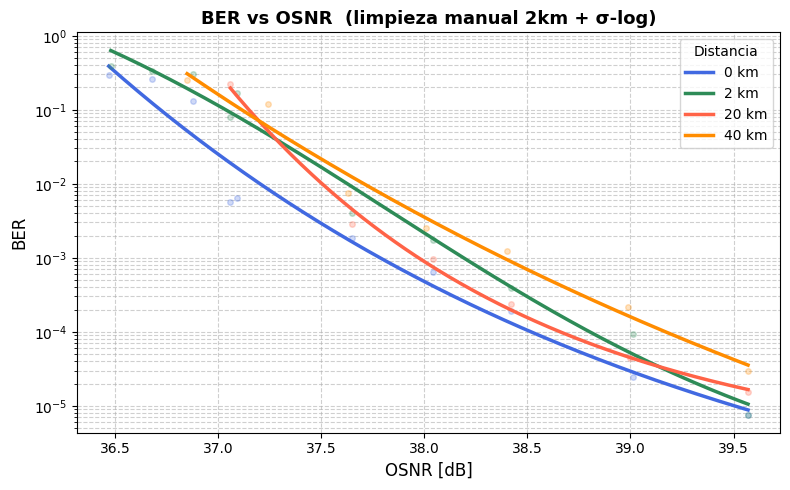

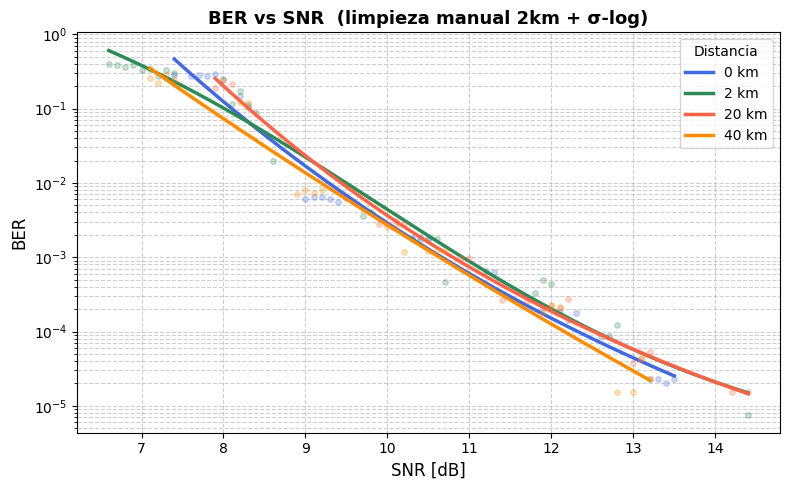

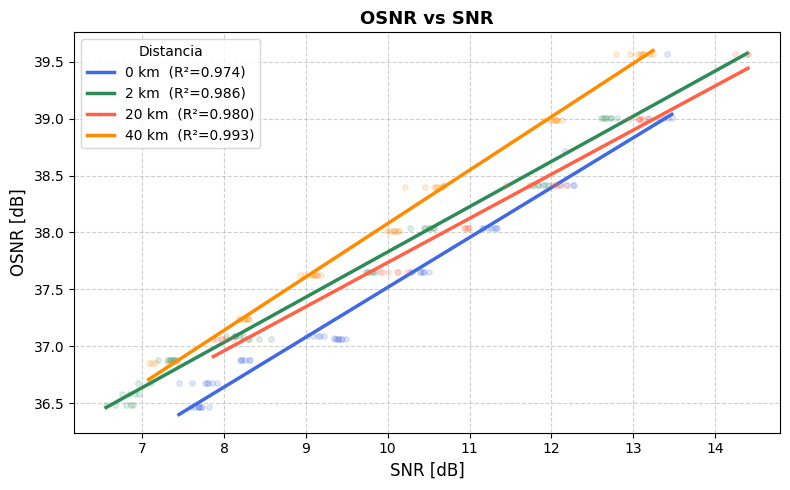

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress

# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

# Cargar el archivo CSV en un DataFrame (tabla) de Pandas
df = pd.read_csv("results_qpsk_dfb_extended_Prueba3.csv")

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS
# ─────────────────────────────────────────────

# Paso 1: Eliminar BER = 0
# El BER = 0 significa que no hubo errores en la simulación, pero el log10(0)
# da menos infinito (-inf), lo que arruinaría las matemáticas de la regresión.
df = df[df['ber'] > 0].copy()

# Paso 2: Eliminar un outlier conocido manualmente
# Se elimina una anomalía física ya identificada en la simulación a 2 km.
# El operador '~' significa NOT: "Conserva todo EXCEPTO lo que cumpla esto".
df = df[~((df['distance_km'] == 2) &
          (df['osnr_db'] > 39) &
          (df['ber'] > 0.01))]

# Paso 3: Limpieza estadística automática (Filtro por Desviación Estándar)
def limpiar_por_sigma_log(df, grupo_cols=['distance_km', 'osnr_db'], n_sigma=1):
    """
    Agrupa los datos por distancia y nivel de OSNR. Convierte el BER a escala
    logarítmica, calcula el promedio y la desviación estándar de cada grupo,
    y descarta los puntos que se alejen demasiado de su promedio local.
    """
    filas_validas = []

    # Iterar sobre cada grupo único (ej. datos de 0km a 35dB de OSNR)
    for keys, grupo in df.groupby(grupo_cols):
        ber = grupo['ber'].values

        # Caso especial 1: Si hay menos de 2 datos, no hay cómo calcular
        # una desviación estándar, así que conservamos el grupo tal cual.
        if len(ber) < 2:
            filas_validas.append(grupo)
            continue

        # Convertir a logaritmo en base 10
        log_ber  = np.log10(ber)
        mean_log = log_ber.mean()  # Promedio de los logaritmos
        std_log  = log_ber.std()   # Desviación estándar de los logaritmos

        # Caso especial 2: Si la desviación es 0 o NaN (todos los valores
        # son idénticos), no hay outliers que eliminar.
        if np.isnan(std_log) or std_log == 0:
            filas_validas.append(grupo)
            continue

        # Máscara booleana: ¿La distancia del dato a la media es menor o
        # igual a "n" desviaciones estándar?
        mask = np.abs(log_ber - mean_log) <= n_sigma * std_log

        # Guardar solo las filas de este grupo que aprobaron el filtro
        filas_validas.append(grupo[mask])

    # Unir todos los grupos limpios de vuelta en una sola tabla y ordenarla
    return pd.concat(filas_validas).sort_index()

# Aplicar la función de limpieza usando n_sigma = 1
df_clean = limpiar_por_sigma_log(df,
                                  grupo_cols=['distance_km', 'osnr_db'],
                                  n_sigma=1)

# Imprimir el resumen de la limpieza para llevar control
print(f"Filas originales         : {len(df)}")
print(f"Filas después de limpieza: {len(df_clean)}")
print(f"Filas eliminadas         : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col, decimals=2):
    """
    Redondea el eje X (OSNR o SNR) y promedia los valores de BER
    que sobrevivieron a la limpieza estadística.
    """
    df = df.copy()
    df[x_col] = df[x_col].round(decimals)
    # Agrupar por eje X y sacar la media del eje Y
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values

def sigmoid_log(x, a, b, c, d):
    """
    Función matemática para la "Curva de Cascada" (Waterfall Curve) del BER.
    Se ajusta al log10 del BER, no al valor lineal.
    """
    return a / (1 + np.exp(b * (x - c))) + d

# Colores para representar cada una de las 4 distancias
COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS = sorted(df_clean['distance_km'].unique())


# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR
# ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    # Aislar datos de una sola distancia
    grupo  = df_clean[df_clean['distance_km'] == dist]

    # Obtener x (OSNR) y y (BER Promedio limpio)
    x, y   = get_mean_curve(grupo, 'osnr_db', 'ber', decimals=2)
    mask   = y > 0
    x_plot, y_plot = x[mask], y[mask]

    # Graficar los PUNTOS con algo de transparencia
    ax1.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    # Intentar hacer el AJUSTE DE CURVA (Fitting)
    try:
        log_y = np.log10(y_plot) # Convertir Y a escala logarítmica

        # curve_fit busca los parámetros a, b, c, d óptimos
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)

        # Crear la línea suave del ajuste con 300 puntos
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        # Devolver a escala lineal usando 10^(y)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)

        # Graficar la LÍNEA SÓLIDA ajustada
        ax1.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"{int(dist)} km")

    except Exception as e:
        # Si la curva no converge, imprime el error y grafica líneas conectando los puntos
        print(f"⚠️ Fitting BER vs OSNR ({int(dist)} km): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"{int(dist)} km")

# Estilos de la gráfica 1
ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.set_title("BER vs OSNR  (limpieza manual 2km + σ-log)", fontsize=13, fontweight='bold')
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_osnr_sigmalog.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR
# ─────────────────────────────────────────────
# (El proceso es idéntico a la Gráfica 1, pero agrupando por SNR)

fig2, ax2 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo  = df_clean[df_clean['distance_km'] == dist]
    x, y   = get_mean_curve(grupo, 'snr_db', 'ber', decimals=1)
    mask   = y > 0
    x_plot, y_plot = x[mask], y[mask]

    ax2.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    try:
        log_y = np.log10(y_plot)
        # Cambio aquí: p0[1] es 1 en vez de 2, porque SNR suele tener una caída más suave
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"{int(dist)} km")
    except Exception as e:
        print(f"⚠️ Fitting BER vs SNR ({int(dist)} km): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"{int(dist)} km")

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.set_title("BER vs SNR  (limpieza manual 2km + σ-log)", fontsize=13, fontweight='bold')
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_snr_sigmalog.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — OSNR vs SNR
# ─────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo    = df_clean[df_clean['distance_km'] == dist]
    df_grupo = grupo[['osnr_db', 'snr_db']].dropna()

    # Promediar el OSNR en función del SNR
    df_mean  = (df_grupo.groupby('snr_db')['osnr_db']
                        .mean().reset_index()
                        .sort_values('snr_db'))

    x_raw = df_mean['snr_db'].values
    y_raw = df_mean['osnr_db'].values

    # Graficar puntos promediados
    ax3.plot(x_raw, y_raw, 'o', color=color,
             markersize=4, alpha=0.15)

    # Hacer una Regresión Lineal pura (porque ambos están en dB, la relación es lineal)
    slope, intercept, r_value, _, _ = linregress(x_raw, y_raw)

    # Crear los puntos para graficar la recta ajustada
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    # Trazar la recta, mostrando el R-cuadrado (bondad del ajuste) en la leyenda
    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=f"{int(dist)} km  (R²={r_value**2:.3f})")

# Estilos de la gráfica 3
ax3.set_xlabel("SNR [dB]", fontsize=12)
ax3.set_ylabel("OSNR [dB]", fontsize=12)
ax3.set_title("OSNR vs SNR", fontsize=13, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("osnr_vs_snr_por_distancia.png", dpi=150)
plt.show()

Filas originales         : 303
Filas después de limpieza: 209
Filas eliminadas         : 94 (31.0%)


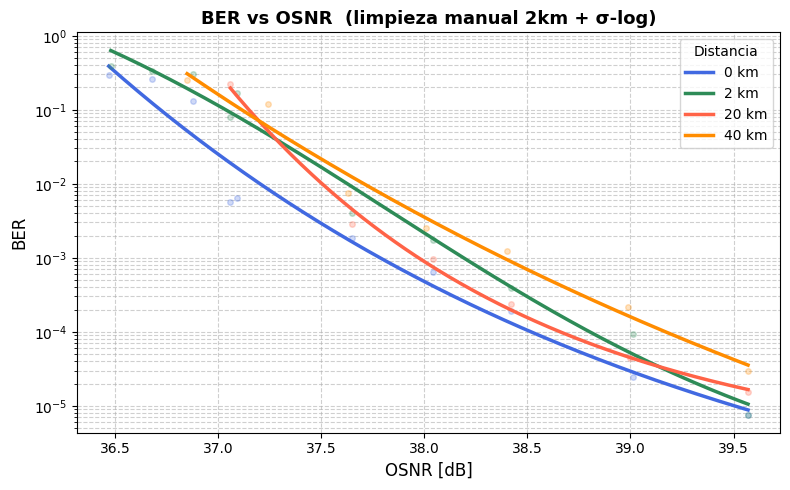

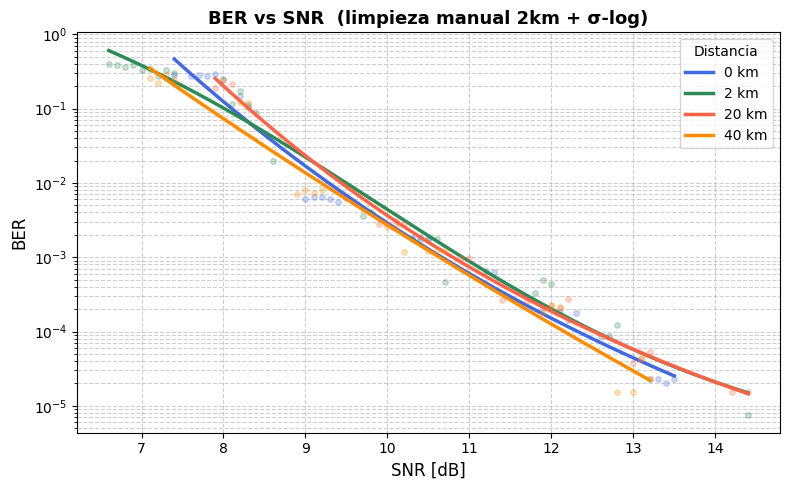

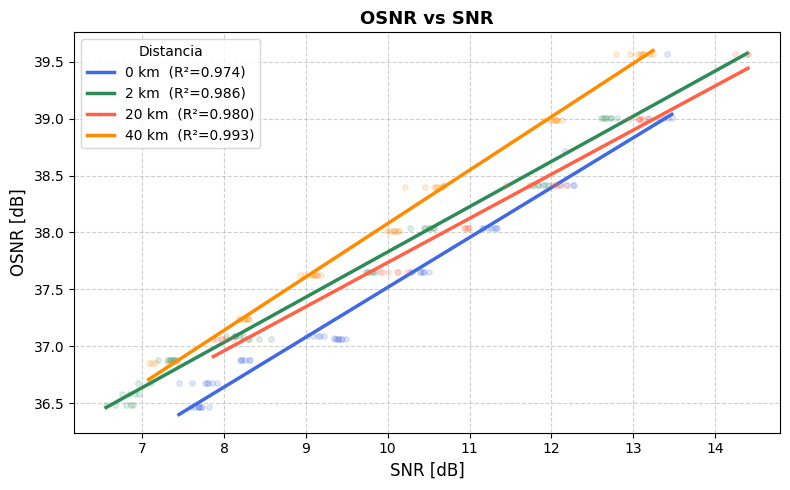

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress

# ─────────────────────────────────────────────
# CARGA DE DATOS
# ─────────────────────────────────────────────

# Cargar el archivo CSV en un DataFrame (tabla) de Pandas
df = pd.read_csv("results_qpsk_dfb_extended_Prueba3.csv")

# ─────────────────────────────────────────────
# LIMPIEZA DE DATOS
# ─────────────────────────────────────────────

# Paso 1: Eliminar BER = 0
# El BER = 0 significa que no hubo errores en la simulación, pero el log10(0)
# da menos infinito (-inf), lo que arruinaría las matemáticas de la regresión.
df = df[df['ber'] > 0].copy()

# Paso 2: Eliminar un outlier conocido manualmente
# Se elimina una anomalía física ya identificada en la simulación a 2 km.
# El operador '~' significa NOT: "Conserva todo EXCEPTO lo que cumpla esto".
df = df[~((df['distance_km'] == 2) &
          (df['osnr_db'] > 39) &
          (df['ber'] > 0.01))]

# Paso 3: Limpieza estadística automática (Filtro por Desviación Estándar)
def limpiar_por_sigma_log(df, grupo_cols=['distance_km', 'osnr_db'], n_sigma=1):
    """
    Agrupa los datos por distancia y nivel de OSNR. Convierte el BER a escala
    logarítmica, calcula el promedio y la desviación estándar de cada grupo,
    y descarta los puntos que se alejen demasiado de su promedio local.
    """
    filas_validas = []

    # Iterar sobre cada grupo único (ej. datos de 0km a 35dB de OSNR)
    for keys, grupo in df.groupby(grupo_cols):
        ber = grupo['ber'].values

        # Caso especial 1: Si hay menos de 2 datos, no hay cómo calcular
        # una desviación estándar, así que conservamos el grupo tal cual.
        if len(ber) < 2:
            filas_validas.append(grupo)
            continue

        # Convertir a logaritmo en base 10
        log_ber  = np.log10(ber)
        mean_log = log_ber.mean()  # Promedio de los logaritmos
        std_log  = log_ber.std()   # Desviación estándar de los logaritmos

        # Caso especial 2: Si la desviación es 0 o NaN (todos los valores
        # son idénticos), no hay outliers que eliminar.
        if np.isnan(std_log) or std_log == 0:
            filas_validas.append(grupo)
            continue

        # Máscara booleana: ¿La distancia del dato a la media es menor o
        # igual a "n" desviaciones estándar?
        mask = np.abs(log_ber - mean_log) <= n_sigma * std_log

        # Guardar solo las filas de este grupo que aprobaron el filtro
        filas_validas.append(grupo[mask])

    # Unir todos los grupos limpios de vuelta en una sola tabla y ordenarla
    return pd.concat(filas_validas).sort_index()

# Aplicar la función de limpieza usando n_sigma = 1
df_clean = limpiar_por_sigma_log(df,
                                  grupo_cols=['distance_km', 'osnr_db'],
                                  n_sigma=1)

# Imprimir el resumen de la limpieza para llevar control
print(f"Filas originales         : {len(df)}")
print(f"Filas después de limpieza: {len(df_clean)}")
print(f"Filas eliminadas         : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col, decimals=2):
    """
    Redondea el eje X (OSNR o SNR) y promedia los valores de BER
    que sobrevivieron a la limpieza estadística.
    """
    df = df.copy()
    df[x_col] = df[x_col].round(decimals)
    # Agrupar por eje X y sacar la media del eje Y
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values

def sigmoid_log(x, a, b, c, d):
    """
    Función matemática para la "Curva de Cascada" (Waterfall Curve) del BER.
    Se ajusta al log10 del BER, no al valor lineal.
    """
    return a / (1 + np.exp(b * (x - c))) + d

# Colores para representar cada una de las 4 distancias
COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS = sorted(df_clean['distance_km'].unique())


# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR
# ─────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    # Aislar datos de una sola distancia
    grupo  = df_clean[df_clean['distance_km'] == dist]

    # Obtener x (OSNR) y y (BER Promedio limpio)
    x, y   = get_mean_curve(grupo, 'osnr_db', 'ber', decimals=2)
    mask   = y > 0
    x_plot, y_plot = x[mask], y[mask]

    # Graficar los PUNTOS con algo de transparencia
    ax1.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    # Intentar hacer el AJUSTE DE CURVA (Fitting)
    try:
        log_y = np.log10(y_plot) # Convertir Y a escala logarítmica

        # curve_fit busca los parámetros a, b, c, d óptimos
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)

        # Crear la línea suave del ajuste con 300 puntos
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        # Devolver a escala lineal usando 10^(y)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)

        # Graficar la LÍNEA SÓLIDA ajustada
        ax1.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"{int(dist)} km")

    except Exception as e:
        # Si la curva no converge, imprime el error y grafica líneas conectando los puntos
        print(f"⚠️ Fitting BER vs OSNR ({int(dist)} km): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"{int(dist)} km")

# Estilos de la gráfica 1
ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.set_title("BER vs OSNR  (limpieza manual 2km + σ-log)", fontsize=13, fontweight='bold')
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_osnr_sigmalog.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR
# ─────────────────────────────────────────────
# (El proceso es idéntico a la Gráfica 1, pero agrupando por SNR)

fig2, ax2 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo  = df_clean[df_clean['distance_km'] == dist]
    x, y   = get_mean_curve(grupo, 'snr_db', 'ber', decimals=1)
    mask   = y > 0
    x_plot, y_plot = x[mask], y[mask]

    ax2.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    try:
        log_y = np.log10(y_plot)
        # Cambio aquí: p0[1] es 1 en vez de 2, porque SNR suele tener una caída más suave
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=f"{int(dist)} km")
    except Exception as e:
        print(f"⚠️ Fitting BER vs SNR ({int(dist)} km): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=f"{int(dist)} km")

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.set_title("BER vs SNR  (limpieza manual 2km + σ-log)", fontsize=13, fontweight='bold')
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_snr_sigmalog.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — OSNR vs SNR
# ─────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(8, 5))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo    = df_clean[df_clean['distance_km'] == dist]
    df_grupo = grupo[['osnr_db', 'snr_db']].dropna()

    # Promediar el OSNR en función del SNR
    df_mean  = (df_grupo.groupby('snr_db')['osnr_db']
                        .mean().reset_index()
                        .sort_values('snr_db'))

    x_raw = df_mean['snr_db'].values
    y_raw = df_mean['osnr_db'].values

    # Graficar puntos promediados
    ax3.plot(x_raw, y_raw, 'o', color=color,
             markersize=4, alpha=0.15)

    # Hacer una Regresión Lineal pura (porque ambos están en dB, la relación es lineal)
    slope, intercept, r_value, _, _ = linregress(x_raw, y_raw)

    # Crear los puntos para graficar la recta ajustada
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    # Trazar la recta, mostrando el R-cuadrado (bondad del ajuste) en la leyenda
    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=f"{int(dist)} km  (R²={r_value**2:.3f})")

# Estilos de la gráfica 3
ax3.set_xlabel("SNR [dB]", fontsize=12)
ax3.set_ylabel("OSNR [dB]", fontsize=12)
ax3.set_title("OSNR vs SNR", fontsize=13, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distancia", fontsize=10)
plt.tight_layout()
plt.savefig("osnr_vs_snr_por_distancia.png", dpi=150)
plt.show()

### Gráficas ajustadas para nuevo LNA y 900 Mhz


Total de filas: 302
SNR  rango: 5.75 — 18.59 dB
OSNR rango: 32.00 — 36.40 dB
BER  rango: 0.00e+00 — 4.97e-01
⚠️ Fitting BER vs OSNR (B2B): The number of func parameters=4 must not exceed the number of data points=2


/tmp/ipykernel_3990/794102652.py:53: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid_log, x_plot, log_y,


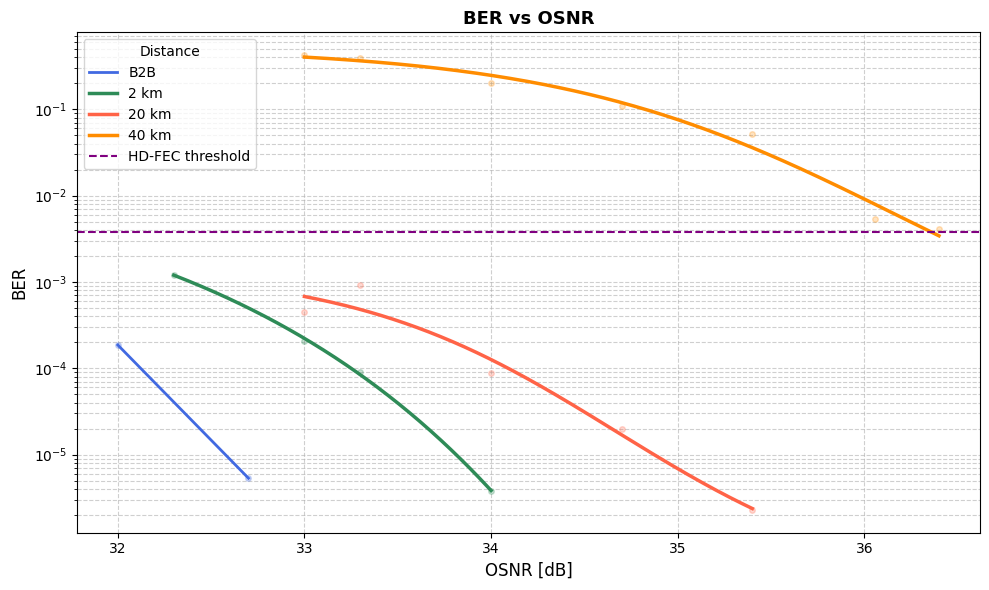

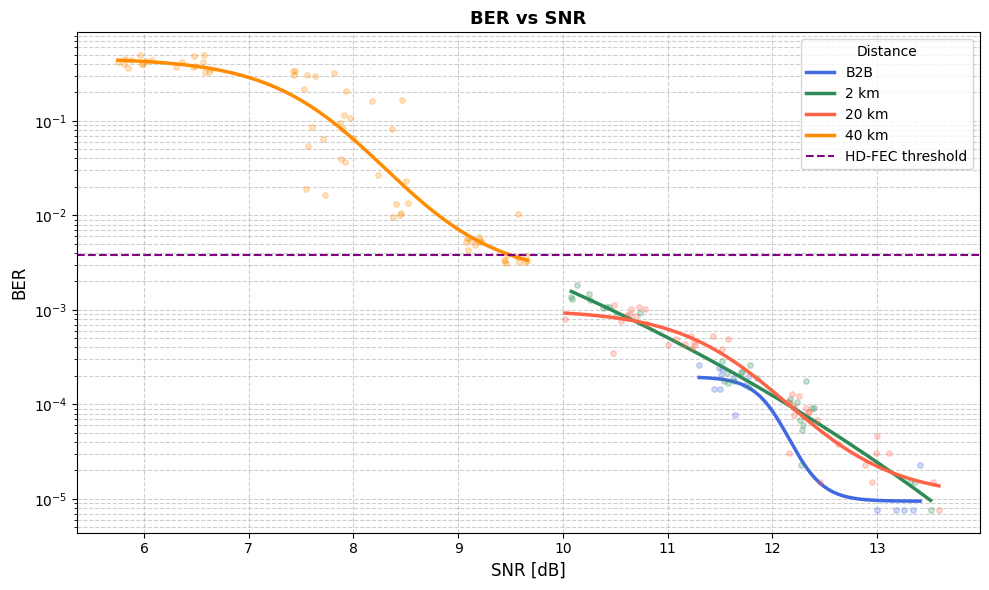

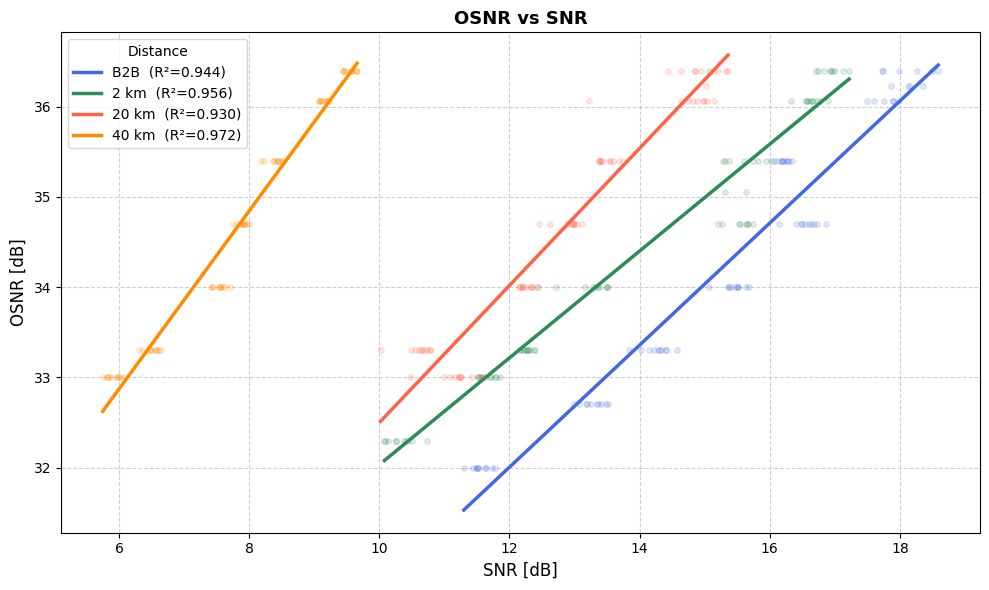

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress

# ─────────────────────────────────────────────
# CARGA DE DATOS — sin limpieza
# ─────────────────────────────────────────────

df_clean = pd.read_csv("results_qpsk_dfb_extended_Prueba8_900.csv")

print(f"Total de filas: {len(df_clean)}")
print(f"SNR  rango: {df_clean['snr_db'].min():.2f} — {df_clean['snr_db'].max():.2f} dB")
print(f"OSNR rango: {df_clean['osnr_db'].min():.2f} — {df_clean['osnr_db'].max():.2f} dB")
print(f"BER  rango: {df_clean['ber'].min():.2e} — {df_clean['ber'].max():.2e}")

# ─────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────

def get_mean_curve(df, x_col, y_col):
    grouped = df.groupby(x_col)[y_col].mean().reset_index()
    grouped = grouped.sort_values(x_col)
    return grouped[x_col].values, grouped[y_col].values

def sigmoid_log(x, a, b, c, d):
    return a / (1 + np.exp(b * (x - c))) + d

def get_label(dist):
    return "B2B" if dist == 0 else f"{int(dist)} km"

COLORS     = ['royalblue', 'seagreen', 'tomato', 'darkorange']
DISTANCIAS = sorted(df_clean['distance_km'].unique())


# ─────────────────────────────────────────────
# GRÁFICA 1 — BER vs OSNR por distancia
# ─────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(10, 6))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo          = df_clean[df_clean['distance_km'] == dist]
    x, y           = get_mean_curve(grupo, 'osnr_db', 'ber')
    x_plot, y_plot = x[y > 0], y[y > 0]

    ax1.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 2, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax1.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs OSNR ({get_label(dist)}): {e}")
        ax1.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax1.set_xlabel("OSNR [dB]", fontsize=12)
ax1.set_ylabel("BER", fontsize=12)
ax1.set_title("BER vs OSNR", fontsize=13, fontweight='bold')
ax1.grid(True, which='both', linestyle='--', alpha=0.6)
ax1.axhline(y=3.8e-3, color='purple', linestyle='--',
            linewidth=1.5, label='HD-FEC threshold')
ax1.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_osnr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 2 — BER vs SNR por distancia
# ─────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(10, 6))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo          = df_clean[df_clean['distance_km'] == dist]
    x, y           = get_mean_curve(grupo, 'snr_db', 'ber')
    x_plot, y_plot = x[y > 0], y[y > 0]

    ax2.semilogy(x_plot, y_plot, 'o', color=color,
                 markersize=4, alpha=0.25)

    try:
        log_y = np.log10(y_plot)
        popt, _ = curve_fit(sigmoid_log, x_plot, log_y,
                            p0=[-6, 1, np.median(x_plot), -6],
                            maxfev=10000)
        x_fit = np.linspace(x_plot.min(), x_plot.max(), 300)
        y_fit = 10 ** sigmoid_log(x_fit, *popt)
        ax2.semilogy(x_fit, y_fit, '-', color=color,
                     linewidth=2.5, label=get_label(dist))
    except Exception as e:
        print(f"⚠️ Fitting BER vs SNR ({get_label(dist)}): {e}")
        ax2.semilogy(x_plot, y_plot, '-', color=color,
                     linewidth=2, label=get_label(dist))

ax2.set_xlabel("SNR [dB]", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.set_title("BER vs SNR", fontsize=13, fontweight='bold')
ax2.grid(True, which='both', linestyle='--', alpha=0.6)
ax2.axhline(y=3.8e-3, color='purple', linestyle='--',
            linewidth=1.5, label='HD-FEC threshold')
ax2.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("ber_vs_snr_por_distancia.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# GRÁFICA 3 — OSNR vs SNR por distancia
# ─────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(10, 6))

for dist, color in zip(DISTANCIAS, COLORS):
    grupo   = df_clean[df_clean['distance_km'] == dist]
    df_mean = (grupo[['osnr_db', 'snr_db']].dropna()
               .groupby('snr_db')['osnr_db'].mean()
               .reset_index().sort_values('snr_db'))

    x_raw = df_mean['snr_db'].values
    y_raw = df_mean['osnr_db'].values

    ax3.plot(x_raw, y_raw, 'o', color=color,
             markersize=4, alpha=0.15)

    slope, intercept, r_value, _, _ = linregress(x_raw, y_raw)
    x_fit = np.linspace(x_raw.min(), x_raw.max(), 300)
    y_fit = slope * x_fit + intercept

    ax3.plot(x_fit, y_fit, '-', color=color, linewidth=2.5,
             label=f"{get_label(dist)}  (R²={r_value**2:.3f})")

ax3.set_xlabel("SNR [dB]", fontsize=12)
ax3.set_ylabel("OSNR [dB]", fontsize=12)
ax3.set_title("OSNR vs SNR", fontsize=13, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(title="Distance", fontsize=10)
plt.tight_layout()
plt.savefig("osnr_vs_snr_por_distancia.png", dpi=150)
plt.show()

### Verificación de datos:


In [ ]:
# Inspecciona los datos crudos de 2 km
df_2km = df[df['distance_km'] == 2]
print(df_2km[['osnr_db', 'ber']].sort_values('osnr_db').to_string())

# Busca outliers: OSNR > 39 dB pero BER > 1e-3
sospechosos = df_2km[(df_2km['osnr_db'] > 39) & (df_2km['ber'] > 1e-3)]
print(sospechosos)

     osnr_db       ber
60     37.06  0.107365
61     37.06  0.104080
62     37.06  0.134865
63     37.06  0.012207
64     37.06  0.088631
65     37.06  0.129158
66     37.06  0.012364
67     37.06  0.012543
68     37.06  0.012530
69     37.06  0.019905
70     37.65  0.004814
71     37.65  0.003601
72     37.65  0.004639
73     37.65  0.003864
74     37.65  0.004318
75     37.65  0.004089
76     37.65  0.004266
77     37.65  0.003906
78     37.65  0.003548
79     37.65  0.003335
80     38.04  0.001579
81     38.04  0.001762
82     38.04  0.001938
83     38.04  0.001747
84     38.04  0.001694
85     38.04  0.001945
86     38.04  0.001793
87     38.04  0.001656
88     38.04  0.001663
89     38.04  0.001862
90     38.42  0.001053
91     38.42  0.000458
92     38.42  0.000328
93     38.42  0.000298
94     38.42  0.000320
95     38.42  0.000389
96     38.42  0.000488
97     38.42  0.000252
98     38.42  0.000435
99     38.42  0.000748
100    39.01  0.000092
101    39.01  0.000084
102    39.0

In [ ]:
def ber_con_piso(x, a, b, c, floor):
    return 10**(a / (1 + np.exp(b*(x - c)))) + floor

## USPL

In [ ]:
POWER = "-3"
FREQ = "650"
DATA_RATE = "1p88"
LASER_TYPE = "uspl"
DISTANCES = [0, 20]
rx_paths_uspl = [f"rof_{LASER_TYPE}_{POWER}dBm_{d}km_{FREQ}mhz_{DATA_RATE}mbps.npz" for d in DISTANCES]

data0, data20 = 0, 0
data_uspl = [data0, data20]

for datum, path in zip(data_uspl, rx_paths_uspl):
  datum = np.load(path, allow_pickle=True)
  print(f"📂 Datos de {path} cargados con {len(datum)} archivos")

📂 Datos de rof_uspl_-3dBm_0km_650mhz_1p88mbps.npz cargados con 55 archivos
📂 Datos de rof_uspl_-3dBm_20km_650mhz_1p88mbps.npz cargados con 50 archivos


### Evaluar

In [ ]:
output_filename_uspl = f"results_qpsk_{LASER_TYPE}.csv"
results_list_uspl, processed_files_uspl = load_results(output_filename_uspl)

✅ Base de datos cargada: 105 registros previos.


In [ ]:
main_pipeline(rx_paths_uspl, processed_files_uspl, results_list_uspl, output_filename_uspl)


📂 NPZ: rof_uspl_-3dBm_0km_650mhz_1p88mbps.npz
⏩ Saltando 55 archivos ya procesados...


Procesando rof_uspl_-3dBm_0km_650mhz_1p88mbps.npz: 0file [00:00, ?file/s]

✅ Progreso guardado. Total en BD: 105


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

Procesando rof_uspl_-3dBm_20km_650mhz_1p88mbps.npz: 0file [00:00, ?file/s]

✅ Progreso guardado. Total en BD: 105


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✨ Pipeline finalizado en 0.07 segundos.
